# Velutina — medical aid to the mountains

**Velutina** is a small printed courier for the last kilometres of a medical delivery in the mountains: blood, a
sample, an antidote, a defibrillator kit — half a kilogram that has to be at a rescue site *now*, where a helicopter
is too slow to call or cannot land. It flies from a valley depot to a site high up at **40 m/s**, in the thin air, in
the valley wind, and delivers in one of two ways:

- **set-down** — a hover descent onto a small pad (a hut yard, a ledge), the capsule released on the ground;
- **hand-over** — where there is nowhere to land (a climber stuck in a pocket of a rock face, a person in a tree), it
  hovers against the wall at arm's reach and the person **takes the capsule by its handle**.

Then it flies home under power. An emergency parachute lives in the tail cone for a failure, not for the landing.

The same machine serves the other jobs where *fast and precise* is the point: **flood rescue** (a line, a radio, a
life vest to someone cut off by water — the hand-over mode from the hover), **rescue-team resupply** (batteries,
medicine, a part, to a team on a ridge), and **environmental sampling** (the capsule swapped for a sampler: water from
a flooded river, air from a plume, set down and picked up again). Each is the mountain mission with another capsule and
another site; the structure, the propulsion and the flight model below do not change.

The machine (`designs/velutina.py`): a slim cylindrical body with an **ogive nose that is the medical capsule**
(removable, with a grab handle), **four short arms near the tail with pusher propellers** (an X seen from the front),
**four cruciform fins** behind them so it flies straight and fast nose first, and the parachute bay in the tail cone.
In fast flight the body lies almost along the flight path (the thrust points along the body axis, the body and the
fins carry the small lift it needs); in hover it stands upright, nose up, the capsule on top where a hand reaches it.

The notebook takes the design end to end — *the electronics are assumed to be there* (autopilot, navigation,
radio; the flight model uses an ideal attitude loop and a stated navigation error):

```
CAD (Dedalus): body, capsule with its handle, arms with motor pods, fins ─► printed masses, CG, the mass budget
aerodynamics: a hand estimate of the drag areas (body, fins, arms, pods), the propeller zones as actuator disks
    (slipstream over the arms and pods), then Aeromant (OpenFOAM) on the whole aircraft at 0° and 10° — a FAST
    preset that runs here in seconds; the FULL preset is in the cell for a longer run
propulsion (Boreas): 7-inch tri-blade pushers, 2807 motors, a 6S pack — hover, full throttle, 35 m/s, at the depot and
    in the thin air at the site; excitation frequencies and noise
structure (Talos): the arm at max thrust, a hard landing and a 15 g inertia case; the capsule at a 15 g nose-down landing
    with its load; the body shell under the parachute's opening shock; their modes against the rotor lines (Campbell)
mission (a reduced 6-DOF flight model, designs/velutina_flight.py): the valley → the site → home, set-down and hand-over,
    wind with gusts, the thin air; set-down precision and station-keeping at the wall over gust realisations; energy
loads over the mission (Chronos): the phases as segments, rotor unbalance, rainflow spectrum, fatigue of the arm, fleet life
printing (Mellonia): the capsule and an arm; the movie of the mission; a JSON record
```

**Scope notes, as asked.** No optimisation here — this is the first working design, every number an input to be
replaced by a better one. The CFD cells are *smoke tests* (coarse mesh, few iterations): the `FULL` preset is written
next to them for a longer run on your machine. **To do** (not in this notebook): the parachute in CFD (opening,
canopy drag, the body in its wake) — the parachute is an analytic estimate here; propeller guard rings for the
hand-over mode (a hand near the rotors); the four propellers as rotor disks in the whole-aircraft CFD (the
`aircraft_rotor_disks` template has two disks; four need a template change); the parachute bridle anchored to the
arm frame instead of the shell (see §5); coupon tests for the printed materials.

**Velutina v2 — infrastructure inspection** (§11–12): the same airframe with a camera nose instead of the capsule
inspects the blades of an onshore wind turbine — a half-real 2 MW machine, parked — flying along each blade at a
standoff and dwelling at suspect points until the video is good enough to judge a crack. Rudimentary aerodynamics
(wind shear, the tower's wind shadow, gusts), a camera model that sets the scan speed and the dwell time, the path, the
flight, the energy, and a movie.

In [ ]:
# DEBUG: test the notebook end to end before the full run. On: FEA and CFD are mocked (vegeta.mock: fixed numbers,
# seconds instead of hours, the result cache off). Turn it on here or from the shell:
#   VEGETA_DEBUG=1 jupyter nbconvert --to notebook --execute <notebook>.ipynb --output <notebook>-run.ipynb
DEBUG = False
from vegeta import mock
DEBUG = mock.setup(DEBUG)

In [1]:
import json, math, os, shutil, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from vegeta import dedalus, talos, aeromant, mellonia, core, boreas, chronos
from vegeta.dedalus import viz as dviz
from vegeta.talos import viz as tviz
from vegeta.aeromant import viz as aviz
from vegeta.mellonia.examples import GENERIC_PLA_0_2MM
sys.path.insert(0, "designs")
import velutina_flight as vf
import velutina_inspection as vi

RUNS = Path("_runs/velutina"); shutil.rmtree(RUNS, ignore_errors=True); RUNS.mkdir(parents=True)
OUT = Path("output/24_velutina"); OUT.mkdir(parents=True, exist_ok=True)       # every movie of this notebook
design_file = RUNS / "velutina.py"
shutil.copy(Path("designs/velutina.py"), design_file)                           # the original stays untouched
design = dedalus.load_design(f"{design_file}:Velutina")
G, RHO0 = 9.81, 1.225
RUN_CFD = os.environ.get("VEGETA_SKIP_OPENFOAM") != "1"
CFD_PRESET = os.environ.get("VELUTINA_CFD", "fast")       # "fast": seconds, a smoke test; "full": a real run (minutes to an hour)
PROCS = int(os.environ.get("VELUTINA_PROCS", "4"))
print(f"CFD: {'on' if RUN_CFD else 'skipped'}, preset {CFD_PRESET}, {PROCS} processes")

CFD: on, preset fast, 4 processes


## 1. The mission and the mass budget

The job (inputs): a depot in the valley at about 600 m, a rescue site at 2400 m, 8.1 km away in plan; a 0.5 kg medical
capsule; a wind of 8 m/s from the south-west in the valley, stronger with altitude, with gusts; a 40 m/s dash; delivery
by set-down on a pad or by hand at a rock face; the flight home on the same battery. The printed parts' masses come
from the CAD volumes and the materials chosen in §5 (body and capsule in a foamed LW-PLA shell, arms in PETG-CF).

In [2]:
JOB = pd.Series({"depot altitude [m ASL]": float(vf.Terrain().depot[2]), "site altitude [m ASL]": float(vf.Terrain().site[2]),
                 "distance in plan [km]": float(np.linalg.norm(vf.Terrain().site[:2] - vf.Terrain().depot[:2]) / 1000),
                 "capsule (medical load) [kg]": 0.5, "dash speed [m/s]": 40.0, "valley wind [m/s]": vf.Wind().speed,
                 "delivery": "set-down on a pad, or hand-over at a wall"}, name="Velutina — the job (inputs)")
display(JOB.to_frame())

p = design.resolve()
parts_cad = {k: design.generate(part=k) for k in ("aircraft", "body", "arm", "capsule", "fin")}
LW_PLA_G_MM3 = 0.60e-3      # foamed LW-PLA shell, printed solid walls (0.6 g/cm^3 effective, assumption)
PETG_CF_G_MM3 = 1.25e-3     # PETG-CF, solid
printed = pd.Series({"body shell + fins (LW-PLA)": parts_cad["body"].volume * LW_PLA_G_MM3,
                     "capsule with handle (LW-PLA)": parts_cad["capsule"].volume * LW_PLA_G_MM3,
                     "arms with pods, 4x (PETG-CF)": 4 * parts_cad["arm"].volume * PETG_CF_G_MM3})
parts = pd.DataFrame([
    ("medical capsule load",                 500.0),
    ("motors 2807-1300KV (4x)",              4 * 62.0),
    ("propellers 7x4 tri-blade (4x)",        4 * 10.0),
    ("4-in-1 ESC 60 A",                      60.0),
    ("autopilot, GNSS, radio, antennas",     50.0),
    ("battery 6S 8000 mAh LiPo",             1020.0),
    ("parachute, bridle, release",           120.0),
    ("wiring, latch, bolts",                 80.0),
] + [(k, round(v, 1)) for k, v in printed.items()], columns=["part", "mass_g"]).set_index("part")
AUW = parts["mass_g"].sum() / 1000
CAPSULE_KG = (parts.loc["medical capsule load", "mass_g"] + parts.loc["capsule with handle (LW-PLA)", "mass_g"]) / 1000
print(f"all-up mass {AUW:.2f} kg (capsule and its load {CAPSULE_KG:.2f} kg); the aircraft comes home at {AUW - CAPSULE_KG:.2f} kg")
parts

,Velutina — the job (inputs)
depot altitude [m ASL],604.443266
site altitude [m ASL],2400.0
distance in plan [km],8.13941
capsule (medical load) [kg],0.5
dash speed [m/s],40.0
valley wind [m/s],8.0
delivery,"set-down on a pad, or hand-over at a wall"


all-up mass 2.60 kg (capsule and its load 0.54 kg); the aircraft comes home at 2.06 kg


,mass_g
part,
medical capsule load,500.0
motors 2807-1300KV (4x),248.0
propellers 7x4 tri-blade (4x),40.0
4-in-1 ESC 60 A,60.0
"autopilot, GNSS, radio, antennas",50.0
battery 6S 8000 mAh LiPo,1020.0
"parachute, bridle, release",120.0
"wiring, latch, bolts",80.0
body shell + fins (LW-PLA),226.0


## 2. The machine (Dedalus)

`designs/velutina.py`: `part="aircraft"` is the whole solid for the CFD and the pictures; `body` the hollow printed shell
with the fins and the arm roots (FEA, printing); `arm` one arm with its pod; `capsule` the hollow nose with its seating
ring and the grab handle; `fin` one fin. Body axis along +X, nose at the origin, free stream along +X.

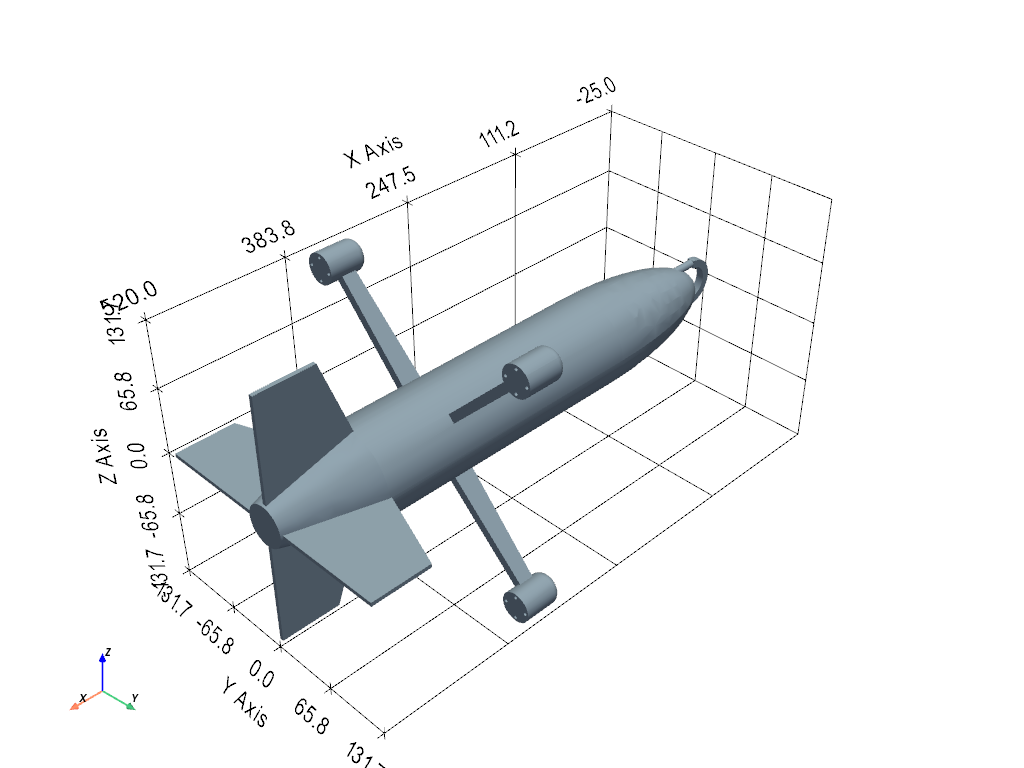

length 545 mm, span over the pods 263 mm, solid volume 3024 cm^3, CAD centre of mass at x = 276 mm (solid, equal density)


,default,units,min,max,description
name,,,,,
part,aircraft,NaN,NaN,NaN,what to build
body_diameter,90.0,mm,40.0,NaN,
body_length,520.0,mm,200.0,NaN,nose tip to tail end
nose_length,150.0,mm,40.0,NaN,the ogive capsule (nose tip to its base joint)
tail_length,90.0,mm,20.0,NaN,tail cone (parachute bay)
tail_end_diameter,40.0,mm,10.0,NaN,
wall,2.0,mm,0.8,NaN,printed shell wall (body and capsule)
arm_x,340.0,mm,50.0,NaN,arm centreline from the nose tip
arm_reach,165.0,mm,60.0,NaN,axis to motor centre


In [3]:
aircraft = parts_cad["aircraft"]
dviz.show(dviz.plot3d(aircraft))
m = aircraft.measure()
print(f"length {m['dimensions'][0]:.0f} mm, span over the pods {m['dimensions'][1]:.0f} mm, solid volume {aircraft.volume / 1000:.0f} cm^3, "
      f"CAD centre of mass at x = {m['center_of_mass'][0]:.0f} mm (solid, equal density)")
pd.DataFrame(design.params.table()).set_index("name")

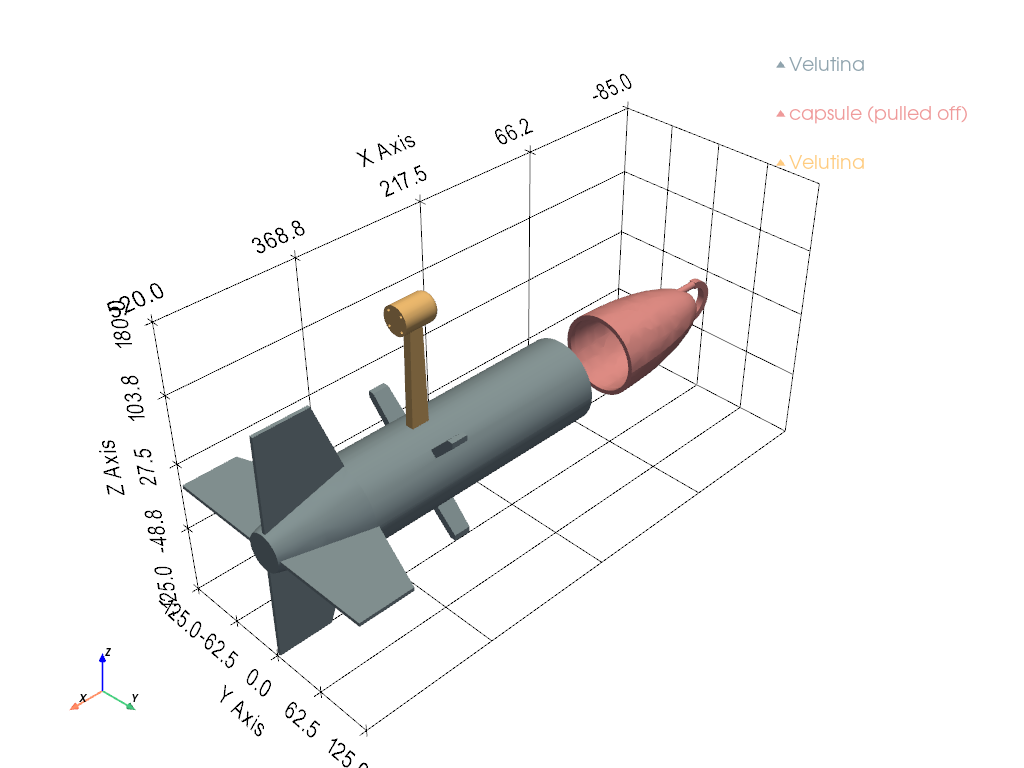

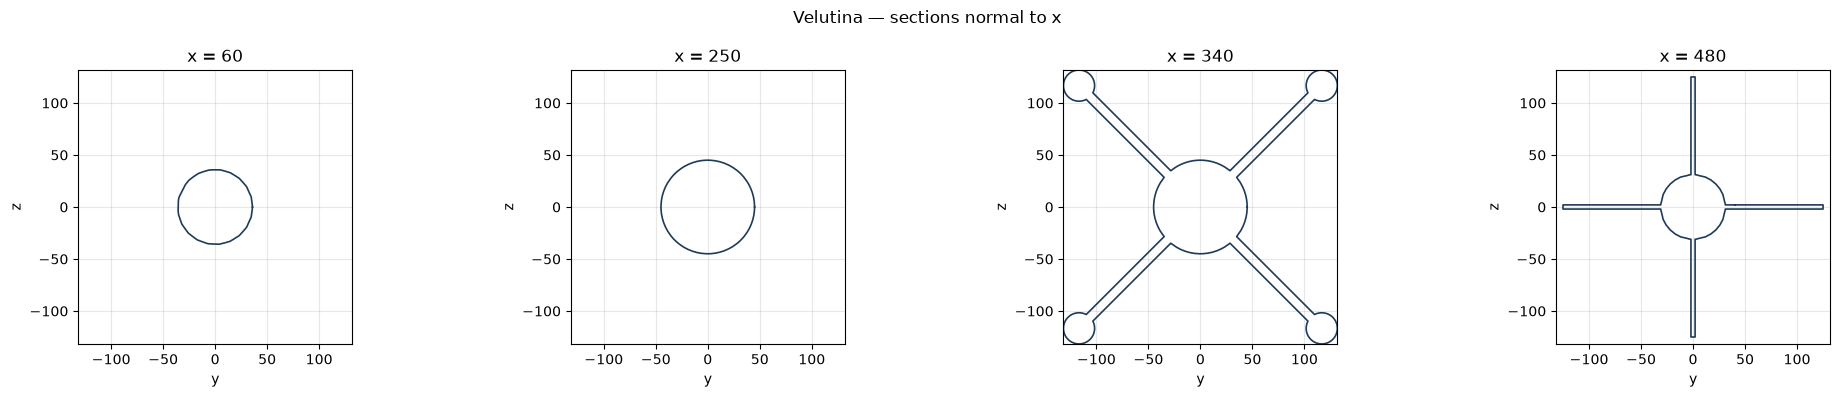

In [4]:
capsule_apart = dedalus.Geometry.from_cadquery(parts_cad["capsule"].shape.translate((-60, 0, 0)), name="capsule (pulled off)")
dviz.show(dviz.plot3d(parts_cad["body"], capsule_apart, parts_cad["arm"], colors=["#90a4ae", "#ef9a9a", "#ffcc80"]))
fig = dviz.plot_sections(aircraft, normal="x", positions=[60.0, 250.0, p["arm_x"], 480.0], cols=4)   # nose, cylinder, through the arms, through the fins

## 3. Aerodynamics

**Hand estimate first.** Drag areas $C_D A$ for the two attitudes the flight model needs: the body *along* the relative
wind (fast flight: skin friction on the body, base drag of the tail cone, the fins and arms at zero incidence, the pods),
and *across* it (hover in a side wind: the body as a cylinder in cross flow, the fins and arms as plates). The
propeller zones are treated as **actuator disks**: the slipstream speed $V_s=\sqrt{V^2+2T/(\rho A)}$ raises the dynamic
pressure on the pods and on the outer part of each arm, which gives a drag increment that grows with thrust.

**Then the CFD.** Aeromant's `rans_ksst_external` on the whole aircraft at 0° and 10° nose-up. The `fast` preset meshes
~10 k cells and runs 150 iterations in seconds — a smoke test of the workflow, not a drag number to trust. The `full`
preset (set `VELUTINA_CFD=full`) is the run to make on your machine. The forces are on the airframe (no propellers);
the disk increment is added analytically below.

In [5]:
MU, NU = 1.8e-5, 1.5e-5
D_B, L_B, L_N, L_T = p["body_diameter"] / 1000, p["body_length"] / 1000, p["nose_length"] / 1000, p["tail_length"] / 1000
S_REF = math.pi * D_B ** 2 / 4                                     # reference area: body cross-section
R_PROP = 0.0889                                                     # 7 inch
A_DISK = math.pi * R_PROP ** 2

def cf_turbulent(re):
    return 0.074 / re ** 0.2

def cda_axial(v):
    re = v * L_B / NU
    wetted_body = aircraft.surface_area / 1e6 - 4 * parts_cad["arm"].surface_area / 1e6 - 4 * parts_cad["fin"].surface_area / 1e6
    body = cf_turbulent(re) * wetted_body * (1 + 1.5 * (D_B / L_B) ** 1.5)      # form factor
    base = 0.12 * math.pi * (p["tail_end_diameter"] / 2000) ** 2                    # blunt tail end
    fins = 4 * 2 * cf_turbulent(v * 0.08 / NU) * (parts_cad["fin"].surface_area / 2e6) * 1.2
    arms = 4 * 1.1 * (p["arm_thickness"] / 1000) * (p["arm_reach"] - D_B * 500) / 1000 * 0.5   # blunt bars edge-on: Cd ~1.1 on t x L, half hidden by the pods' flow
    pods = 4 * 0.25 * math.pi * (p["pod_diameter"] / 2000) ** 2
    return {"body": body, "base": base, "fins": fins, "arms": arms, "pods": pods, "total": body + base + fins + arms + pods}

def cda_cross():
    body = 1.0 * D_B * (L_B - L_N - L_T) + 0.5 * D_B * L_N * 0.7 + 0.6 * 0.5 * (D_B + p["tail_end_diameter"] / 1000) * L_T
    fins = 1.2 * 2 * (p["fin_span"] / 1000) * 0.5 * (p["fin_root_chord"] + p["fin_tip_chord"]) / 1000     # the two fins across the wind
    arms = 1.2 * 2 * (p["arm_width"] / 1000) * (p["arm_reach"] - D_B * 500) / 1000 * (1 + p["arm_taper"]) / 2
    pods = 4 * 0.8 * (p["pod_diameter"] / 1000) * (p["pod_length"] / 1000)
    return {"body": body, "fins": fins, "arms": arms, "pods": pods, "total": body + fins + arms + pods}

HAND_AXIAL, HAND_CROSS = cda_axial(35.0), cda_cross()
est = pd.DataFrame({"axial, 35 m/s [m^2]": HAND_AXIAL, "cross flow [m^2]": HAND_CROSS}).fillna(0.0)
est.loc["Cd on body cross-section"] = est.loc["total"] / S_REF
print(f"body Re at 35 m/s: {35 * L_B / NU:.2e}; reference area {S_REF * 1e4:.1f} cm^2")
est.round(5)

body Re at 35 m/s: 1.21e+06; reference area 63.6 cm^2


,"axial, 35 m/s [m^2]",cross flow [m^2]
body,0.00060,0.03344
base,0.00015,0.00000
fins,0.00058,0.01536
arms,0.00238,0.00490
pods,0.00071,0.00384
total,0.00442,0.05753
Cd on body cross-section,0.69401,9.04330


In [6]:
PRESETS = {"fast": dict(iterations=150, residual_target=1e-4, surface_level=3, near_level=2, wake_level=1, cells_per_length=1.5),
           "full": dict(iterations=800, residual_target=1e-4, surface_level=5, near_level=3, wake_level=2, cells_per_length=3.0)}
STL_TOL = {"fast": 0.3, "full": 0.08}[CFD_PRESET]
V_CFD = 35.0
ws = core.Workspace.create(RUNS / "workspace", name="Velutina")
vel = ws.add_design("velutina", f"{design_file}:Velutina")
cfd_revs = {aoa: vel.new_revision(note=f"whole aircraft, {aoa:g} deg nose-up, for CFD", angle_of_attack_deg=aoa) for aoa in (0.0, 10.0)}
for r in cfd_revs.values():
    r.generate(stl_tolerance=STL_TOL)
cases = {}

def external(rev, workdir):
    case = aeromant.CFDCase("rans_ksst_external", rev.stl,
                            dict(velocity=V_CFD, kinematic_viscosity=NU, density=RHO0, reference_area=S_REF, reference_length=L_B,
                                 center_of_rotation=(L_B / 2, 0.0, 0.0), **PRESETS[CFD_PRESET]),
                            workdir=workdir, geometry_units="mm", environment=aeromant.OpenFOAMEnvironment.detect())
    cases[rev.id] = case
    return case

ev_cfd = {}
for aoa, rev in cfd_revs.items():
    ev_cfd[aoa] = rev.run_cfd(f"aoa_{aoa:g}", external, progress=True, processors=PROCS) if RUN_CFD else None
    print(f"{aoa:g} deg:", ev_cfd[aoa] if ev_cfd[aoa] is not None else "CFD skipped (VEGETA_SKIP_OPENFOAM=1)")
ws.status()

aeromant:   0%|          | 00:00 

0 deg: cfd:aoa_0 SUCCESS
  mesh_cells                   10368
  mesh_ok                      True
  mesh_failed_checks           0
  reynolds_number              1213333.3333333333
  iterations                   150
  converged                    True
  Cd                           0.425578377
  Cd_mean_last50               0.42557534520000007
  Cd_std_last50                3.5156075548881263e-06
  Cl                           -0.16361758
  Cl_mean_last50               -0.16363901414
  Cl_std_last50                2.29287685853454e-05
  Cm                           0.0600489254
  Cm_mean_last50               0.060058976991999996
  Cm_std_last50                1.0036700388391445e-05
  drag_force_N                 2.0314055561946693
  lift_force_N                 -0.7809928301482428


aeromant:   0%|          | 00:00 

10 deg: cfd:aoa_10 SUCCESS
  mesh_cells                   10068
  mesh_ok                      True
  mesh_failed_checks           0
  reynolds_number              1213333.3333333333
  iterations                   145
  converged                    True
  Cd                           0.305459531
  Cd_mean_last50               0.30548337195999997
  Cd_std_last50                1.899477946169937e-05
  Cl                           0.666302465
  Cl_mean_last50               0.6663256009999999
  Cl_std_last50                2.0009723316423315e-05
  Cm                           0.0774385151
  Cm_mean_last50               0.077417520276
  Cm_std_last50                1.632016199015808e-05
  drag_force_N                 1.4580444449272805
  lift_force_N                 3.180449483943599


rev,design,parent,label,changes,CAD,cfd:aoa_0,cfd:aoa_10
r1,velutina,-,unclassified,-,V=3.024e+06,Cd=0.426 Cl=-0.164,NOT RUN
r2,velutina,-,unclassified,angle_of_attack_deg=10.0,V=3.024e+06,NOT RUN,Cd=0.305 Cl=0.666


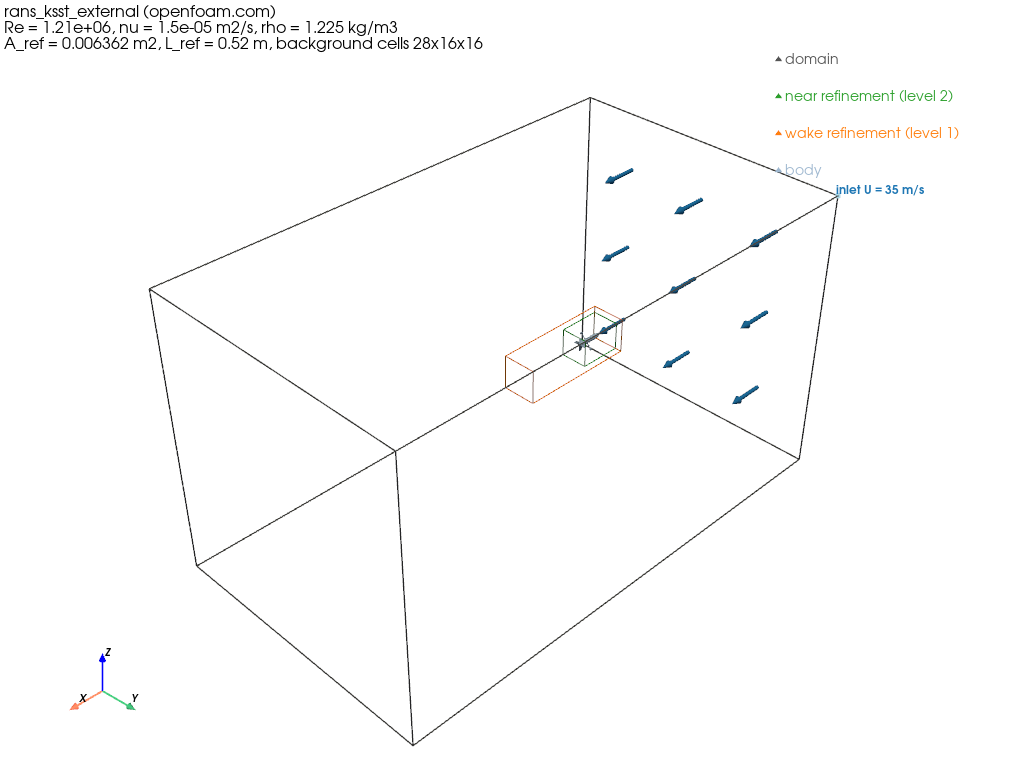

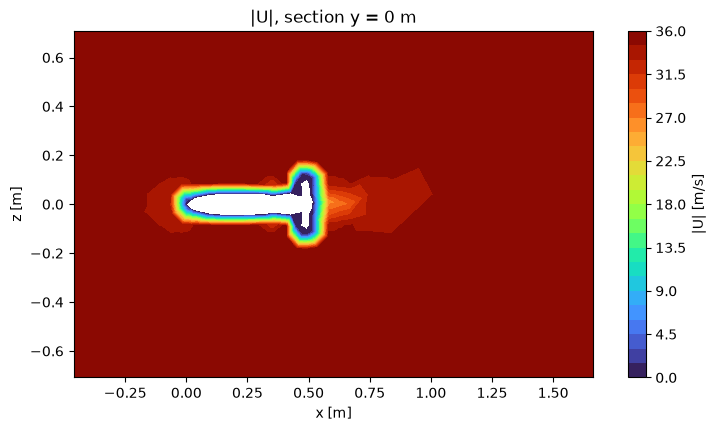

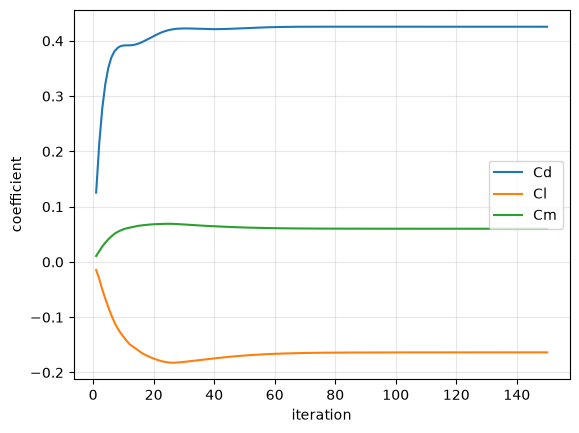

In [7]:
if ev_cfd[0.0] is not None:
    aviz.show(aviz.plot_setup(cases[cfd_revs[0.0].id]))
if ev_cfd[0.0] is not None and ev_cfd[0.0].ok:
    fig = aviz.plot_section(cases[cfd_revs[0.0].id], "U", normal="y", origin=(L_B / 2, 0.0, 0.0), zoom=1.3)
    fig = aeromant.plot_coefficients(cases[cfd_revs[0.0].id].workdir)

In [8]:
q_cfd = 0.5 * RHO0 * V_CFD ** 2
rows = {"hand estimate": {"CdA_axial_m2": HAND_AXIAL["total"], "Cd": HAND_AXIAL["total"] / S_REF, "drag_N_at_35": q_cfd * HAND_AXIAL["total"], "Cl": 0.0}}
for aoa, ev in ev_cfd.items():
    if ev is not None and ev.ok:
        rows[f"CFD {aoa:g} deg ({CFD_PRESET}, {ev.metrics['mesh_cells']} cells, {'converged' if ev.metrics['converged'] else 'NOT converged'})"] = {
            "CdA_axial_m2": ev.metrics["Cd"] * S_REF, "Cd": ev.metrics["Cd"], "drag_N_at_35": ev.metrics["drag_force_N"], "Cl": ev.metrics["Cl"],
            "lift_N_at_35": ev.metrics["lift_force_N"], "Cm": ev.metrics["Cm"]}
aero = pd.DataFrame(rows).T
display(aero.round(4))
# what the flight model uses: the CFD at 0 deg when it ran, else the hand estimate; cross flow always from the hand estimate
CDA_AXIAL = float(ev_cfd[0.0].metrics["Cd"] * S_REF) if (ev_cfd[0.0] is not None and ev_cfd[0.0].ok) else HAND_AXIAL["total"]
CDA_CROSS = HAND_CROSS["total"]
print(f"flight model drag areas: axial {CDA_AXIAL * 1e4:.1f} cm^2 ({'CFD' if ev_cfd[0.0] is not None and ev_cfd[0.0].ok else 'hand estimate'}), cross flow {CDA_CROSS * 1e4:.0f} cm^2 (hand estimate)")

,CdA_axial_m2,Cd,drag_N_at_35,Cl,lift_N_at_35,Cm
hand estimate,0.0044,0.6940,3.3127,0.0000,NaN,NaN
"CFD 0 deg (fast, 10368 cells, converged)",0.0027,0.4256,2.0314,-0.1636,-0.7810,0.0600
"CFD 10 deg (fast, 10068 cells, converged)",0.0019,0.3055,1.4580,0.6663,3.1804,0.0774


flight model drag areas: axial 27.1 cm^2 (CFD), cross flow 575 cm^2 (hand estimate)


at 35 m/s: airframe drag 2.03 N, slipstream increment 0.28 N (14 %), thrust for level flight 25.6 N of 25.5 N weight (axis tilted 5° from the vertical)


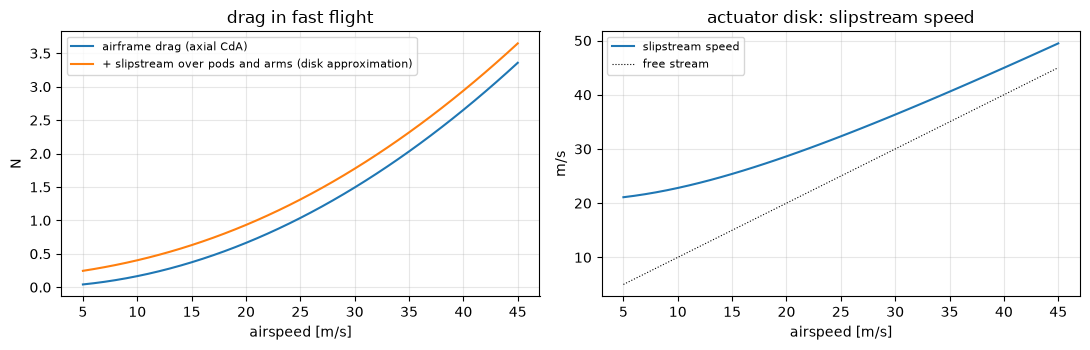

In [9]:
# the propeller zones as actuator disks: the slipstream over the pods and the outer arms
def disk_increment(v, thrust_total, rho=RHO0):
    T = thrust_total / 4
    v_s = math.sqrt(v ** 2 + 2 * T / (rho * A_DISK))                  # far slipstream speed (momentum theory)
    v_disk = 0.5 * (v + v_s)                                            # at the disk plane (the pods sit in it)
    in_slip = 4 * (0.25 * math.pi * (p["pod_diameter"] / 2000) ** 2) + 4 * 1.1 * (p["arm_thickness"] / 1000) * 0.9 * R_PROP * 0.5
    return 0.5 * rho * in_slip * (v_disk ** 2 - v ** 2), v_s

W = AUW * G
Vs = np.linspace(5, 45, 41)
D_air = np.array([0.5 * RHO0 * v ** 2 * CDA_AXIAL for v in Vs])
T_level = np.sqrt(W ** 2 + D_air ** 2)                                  # thrust along the tilted axis: weight and drag
dD = np.array([disk_increment(v, t)[0] for v, t in zip(Vs, T_level)])
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(Vs, D_air, label="airframe drag (axial CdA)"); ax[0].plot(Vs, D_air + dD, label="+ slipstream over pods and arms (disk approximation)")
ax[0].set(xlabel="airspeed [m/s]", ylabel="N", title="drag in fast flight"); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
ax[1].plot(Vs, [disk_increment(v, t)[1] for v, t in zip(Vs, T_level)], label="slipstream speed"); ax[1].plot(Vs, Vs, "k:", lw=0.8, label="free stream")
ax[1].set(xlabel="airspeed [m/s]", ylabel="m/s", title="actuator disk: slipstream speed"); ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
fig.tight_layout()
i35 = int(np.argmin(abs(Vs - 35)))
print(f"at 35 m/s: airframe drag {D_air[i35]:.2f} N, slipstream increment {dD[i35]:.2f} N ({100 * dD[i35] / D_air[i35]:.0f} %), "
      f"thrust for level flight {T_level[i35]:.1f} N of {W:.1f} N weight (axis tilted {math.degrees(math.atan2(D_air[i35] + dD[i35], W)):.0f}° from the vertical)")
CDA_AXIAL_EFF = CDA_AXIAL + dD[i35] / (0.5 * RHO0 * 35 ** 2)           # the increment folded into the flight model's axial drag area

## 4. Propulsion (Boreas)

Four 7×4 tri-blade pushers on 2807-1300KV motors from a 6S 8000 mAh pack. BEMT with a generic planform and an assumed
section polar (fit them to the real propeller for better numbers). Points: hover with the capsule at the depot's air
density and in the thin air at the site, full throttle static, and full throttle at 35 m/s (the pusher's thrust falls
with speed). The hover power and the full-throttle thrust feed the flight model; the rpm feed the vibration section.

In [10]:
RHO_SITE = float(vf.isa_density(JOB["site altitude [m ASL]"])); RHO_DEPOT = float(vf.isa_density(JOB["depot altitude [m ASL]"]))
d, pitch = boreas.inches(7, 4)
prop = boreas.Propeller.from_pitch("7x4 tri-blade", d, pitch, blades=3, chord_root_m=0.014, chord_max_m=0.020, chord_tip_m=0.007,
                                   mass_kg=0.010, rotor_mass_kg=0.040, notes="generic planform; fit chord/beta to the real propeller")
airfoil = boreas.Airfoil(name="thin cambered section", cl_alpha=2 * math.pi * 0.9, alpha0_deg=-3.0, cl_max=1.1, cd0=0.025, k=0.045,
                         source="assumed for a moulded 7-inch blade at Re ~ 1.5e5")
motor = boreas.Motor("2807-1300KV", kv_rpm_per_volt=1300, resistance_ohm=0.045, no_load_current_a=1.2, max_current_a=50, mass_kg=0.062)
battery = boreas.Battery("6S 8000 mAh LiPo", cells=6, capacity_ah=8.0, usable_fraction=0.85, mass_kg=1.02)
sys_sl = boreas.Propulsion(prop, airfoil, motor, battery, rho=RHO0)
sys_depot = boreas.Propulsion(prop, airfoil, motor, battery, rho=RHO_DEPOT)
sys_site = boreas.Propulsion(prop, airfoil, motor, battery, rho=RHO_SITE)
HOVER_T = W / 4
pts = {"hover, sea level": sys_sl.for_thrust(HOVER_T), "hover at the depot": sys_depot.for_thrust(HOVER_T),
       "hover at the site (thin air)": sys_site.for_thrust(HOVER_T), "hover at the site, capsule gone": sys_site.for_thrust((AUW - CAPSULE_KG) * G / 4),
       "full throttle, static, sea level": sys_sl.at_throttle(1.0), "full throttle, static, at the site": sys_site.at_throttle(1.0),
       "full throttle at 35 m/s, depot": sys_depot.at_throttle(1.0, 35.0)}
tbl = pd.DataFrame({k: {"throttle": v.throttle, "rpm": v.rpm, "thrust_N_per_motor": v.thrust, "thrust_N_total": 4 * v.thrust, "current_A": v.current,
                        "electrical_W_total": 4 * v.electrical_power, "prop_eff_or_FM": v.aero.efficiency if v.aero.airspeed > 0 else float("nan"),
                        "current_limited": v.current_limited} for k, v in pts.items()}).T
print(f"air density: sea level {RHO0}, depot {RHO_DEPOT:.3f}, site {RHO_SITE:.3f} kg/m^3 ({100 * (1 - RHO_SITE / RHO0):.0f} % thinner)")
print(f"thrust-to-weight at full throttle: {4 * pts['full throttle, static, sea level'].thrust / W:.2f} at sea level, "
      f"{4 * pts['full throttle, static, at the site'].thrust / W:.2f} at the site"
      + ("  — CURRENT LIMITED: the full-throttle point is beyond the motor's 50 A; the ESC limit decides, the thrust available is less" if pts['full throttle, static, sea level'].current_limited else ""))
print(f"hover endurance with the capsule: {battery.usable_wh / tbl.loc['hover at the depot', 'electrical_W_total'] * 60:.1f} min on {battery.usable_wh:.0f} Wh usable")
tbl.round(2)

air density: sea level 1.225, depot 1.155, site 0.967 kg/m^3 (21 % thinner)
thrust-to-weight at full throttle: 4.93 at sea level, 4.08 at the site  — CURRENT LIMITED: the full-throttle point is beyond the motor's 50 A; the ESC limit decides, the thrust available is less
hover endurance with the capsule: 17.4 min on 151 Wh usable


,throttle,rpm,thrust_N_per_motor,thrust_N_total,current_A,electrical_W_total,prop_eff_or_FM,current_limited
"hover, sea level",0.421021,11358.670146,6.387046,25.548183,13.538467,506.158316,NaN,False
hover at the depot,0.432689,11695.398295,6.387046,25.548183,13.538467,520.185341,NaN,False
hover at the site (thin air),0.47051,12786.910267,6.387046,25.548183,13.538467,565.654261,NaN,False
"hover at the site, capsule gone",0.416376,11375.201748,5.054603,20.21841,10.964459,405.402359,NaN,False
"full throttle, static, sea level",1.0,25228.906702,31.509529,126.038116,62.069971,5511.813416,NaN,True
"full throttle, static, at the site",1.0,25841.778542,26.086367,104.345466,51.593529,4581.505392,NaN,True
"full throttle at 35 m/s, depot",1.0,26340.359852,14.304189,57.216757,43.070772,3824.684533,0.590122,False


at the 50 A limit: throttle 0.88, 22496 rpm, 100.2 N total -> thrust-to-weight 3.92 (this is the flight model's limit)


,rpm,shaft_hz,blade_pass_hz,unbalance_force_n,unbalance_grade_mm_s
"hover, sea level",11358.67,189.31,567.93,0.30,6.3
hover at the depot,11695.40,194.92,584.77,0.31,6.3
hover at the site (thin air),12786.91,213.12,639.35,0.34,6.3
"hover at the site, capsule gone",11375.20,189.59,568.76,0.30,6.3
"full throttle, static, sea level",25228.91,420.48,1261.45,0.67,6.3


,BPF_hz,one_rotor_dB_1m,four_rotors_dB_1m,four_rotors_dB_10m
hover at the depot,584.8,107.8,113.9,93.9
"full throttle, static, sea level",1261.4,127.9,133.9,113.9


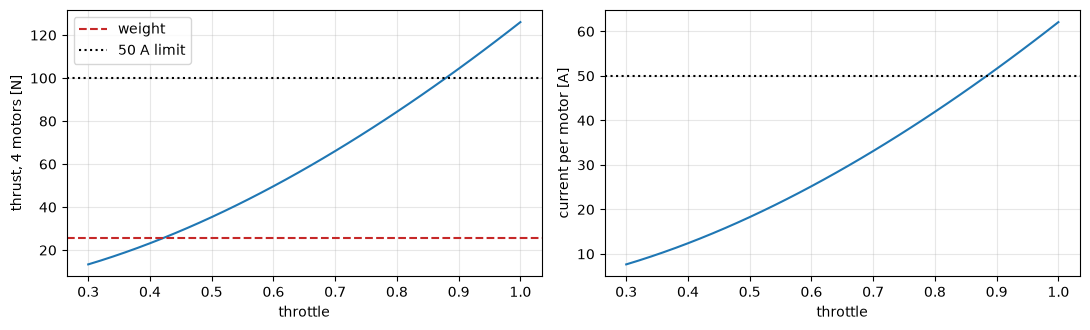

In [11]:
# the thrust the ESC limit really allows: the throttle at which the motor reaches 50 A
I_LIMIT = motor.max_current_a
th = np.linspace(0.3, 1.0, 36)
sw = sys_sl.sweep(th)
ok = [s for s in sw if s.current <= I_LIMIT]
T_LIMIT_SL = 4 * ok[-1].thrust
print(f"at the {I_LIMIT:.0f} A limit: throttle {ok[-1].throttle:.2f}, {ok[-1].rpm:.0f} rpm, {T_LIMIT_SL:.1f} N total -> thrust-to-weight {T_LIMIT_SL / W:.2f} (this is the flight model's limit)")
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot([s.throttle for s in sw], [4 * s.thrust for s in sw]); ax[0].axhline(W, color="#c62828", ls="--", label="weight"); ax[0].axhline(T_LIMIT_SL, color="k", ls=":", label=f"{I_LIMIT:.0f} A limit")
ax[0].set(xlabel="throttle", ylabel="thrust, 4 motors [N]"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot([s.throttle for s in sw], [s.current for s in sw]); ax[1].axhline(I_LIMIT, color="k", ls=":"); ax[1].set(xlabel="throttle", ylabel="current per motor [A]"); ax[1].grid(alpha=0.3)
fig.tight_layout()
# what the structure feels, and the noise
exc = {k: boreas.excitations(prop, v.rpm) for k, v in pts.items() if "hover" in k or "full throttle, static, sea level" in k}
noise = {}
for k in ("hover at the depot", "full throttle, static, sea level"):
    v = pts[k]
    tones = boreas.gutin_harmonics(prop, v.thrust, v.aero.torque, v.rpm, 1.0, 90.0, boreas.AIR, harmonics=6)
    bb = boreas.broadband_level(prop, v.thrust, v.rpm, 1.0, boreas.AIR)
    one = 10 * math.log10(10 ** (tones["total_tonal_db"] / 10) + 10 ** (bb / 10))
    noise[k] = {"BPF_hz": tones["blade_pass_hz"], "one_rotor_dB_1m": one, "four_rotors_dB_1m": one + 10 * math.log10(4), "four_rotors_dB_10m": one + 10 * math.log10(4) - 20}
display(pd.DataFrame(exc).T.round(2)); pd.DataFrame(noise).T.round(1)

## 5. Structure (Talos)

Three parts, three questions:

- **the arm** (PETG-CF, 20 × 9 mm tapered bar with the pod): the motor's thrust at the current limit, a hard landing on one
  pod (a 40 N side load), and a 15 g inertia case with the motor's mass on the pod — fixed at its root face;
- **the capsule** (LW-PLA shell with the handle): a 15 g nose-down landing with the 0.5 kg load pressing on the inside
  of the nose, fixed at its seating ring — the shell wall and the handle legs;
- **the body shell** (LW-PLA): the **parachute's opening shock** pulling at the tail end, the arm roots holding (the
  arms, motors and battery are the inertia that reacts it). The shock itself is the analytic estimate of §7.

Material values are nominal filament numbers (printed solid, XY orientation) — coupon tests replace them. Linear
static, first-order.

In [12]:
PETG_CF = talos.Material("PETG-CF", youngs_modulus=4800.0, poissons_ratio=0.38, density=1.25e-9, yield_strength=45.0, source="nominal filament datasheet, XY")
LW_PLA = talos.Material("LW-PLA shell (solid-equivalent)", youngs_modulus=1200.0, poissons_ratio=0.35, density=0.60e-9, yield_strength=14.0, source="assumed; replace with coupon tests")
cad = {k: parts_cad[k].export(RUNS / f"cad_{k}", formats=("step", "stl"), stl_tolerance=0.05) for k in ("arm", "capsule", "body")}
STEP = {k: v.artifacts["step"] for k, v in cad.items()}

# parachute opening shock (analytic, §7): the aircraft without its capsule, from cruise height, a 1.1 m^2 CdA canopy
CHUTE_CDA = 1.1
chute = vf.parachute_descent(AUW - CAPSULE_KG, JOB["site altitude [m ASL]"] + 120, JOB["site altitude [m ASL]"] - 300, CHUTE_CDA, vf.Wind(), vf.Terrain().base)
SHOCK_N = chute["opening_shock_N"]
print(f"parachute (analytic): terminal {chute['terminal_speed_m_s']:.1f} m/s, opening shock {SHOCK_N:.0f} N ({chute['shock_g']:.0f} g) — the shell's load case")

# --- the arm: root face at the body surface (z = D/2), motor bolt holes and pod faces at the tip
D2, ax_, R_ = p["body_diameter"] / 2, p["arm_x"], p["arm_reach"]
ARM_REGIONS = [talos.SurfacesInBox("root", (ax_ - 30, -20, D2 - 0.5, ax_ + 30, 20, D2 + 0.5)),
               talos.SurfacesInBox("motor", (ax_ + p["pod_length"] / 2 - 11, -15, R_ - 15, ax_ + p["pod_length"] / 2 + 1, 15, R_ + 15))]
ARM_MASSES = [talos.PointMass("motor", (0.062 + 0.010) * 1e-3)]            # motor + propeller [t]
T_MOTOR = T_LIMIT_SL / 4
def arm_model(loads, name):
    return talos.StructuralModel(STEP["arm"], "mm-N-MPa", PETG_CF, ARM_REGIONS, [talos.FixedSupport("root")], loads,
                                 talos.MeshSettings(element_size=3.0), name=name, masses=ARM_MASSES)
ARM_CASES = {"thrust": arm_model([talos.Force("motor", fx=-T_MOTOR)], "thrust"),                            # a pusher pulls its pod forward (-X)
             "landing": arm_model([talos.Force("motor", fy=40.0)], "landing"),                              # one pod hits the ground sideways
             "inertia_15g": arm_model([talos.Acceleration(0.0, 0.0, -15 * 9810.0)], "inertia_15g"),       # radial, the motor mass on the pod
             "lateral_unit": arm_model([talos.Force("motor", fy=1.0)], "lateral_unit")}                      # unit case for the fatigue (rotor unbalance)

# --- the capsule: seating ring (x 144..150), the load on the inner nose surface (the inner surface of revolution)
info_c = talos.inspect_step(STEP["capsule"], units="mm-N-MPa")
inner = min((s for s in info_c.surfaces if s.kind.startswith("Surface of Revolution")), key=lambda s: s.area)
CAP_REGIONS = [talos.SurfacesInBox("ring", (143.5, -46, -46, 150.5, 46, 46)), talos.Surfaces("inner", [inner.tag])]
CAP_MASSES = [talos.PointMass("inner", 0.5e-3)]
def cap_model(loads, name):
    return talos.StructuralModel(STEP["capsule"], "mm-N-MPa", LW_PLA, CAP_REGIONS, [talos.FixedSupport("ring")], loads,
                                 talos.MeshSettings(element_size=4.0), name=name, masses=CAP_MASSES)
CAP_CASES = {"landing_15g_nose": cap_model([talos.Acceleration(-15 * 9810.0, 0.0, 0.0)], "landing_15g_nose"),
             "landing_6g_side": cap_model([talos.Acceleration(0.0, 0.0, -6 * 9810.0)], "landing_6g_side")}

# --- the body shell: arm stubs hold, the shock pulls at the tail ring; the capsule's mass at the joint bulkhead
BODY_REGIONS = [talos.SurfacesInBox("stubs", (ax_ - 12, -60, -60, ax_ + 12, 60, 60)),
                talos.SurfacesInBox("tail", (p["body_length"] - 1, -25, -25, p["body_length"] + 1, 25, 25)),
                talos.SurfacesInBox("joint", (p["nose_length"] - 1, -46, -46, p["nose_length"] + 1, 46, 46))]
def body_model(loads, name):
    return talos.StructuralModel(STEP["body"], "mm-N-MPa", LW_PLA, BODY_REGIONS, [talos.FixedSupport("stubs")], loads,
                                 talos.MeshSettings(element_size=6.0), name=name, masses=[talos.PointMass("joint", CAPSULE_KG * 1e-3)])
BODY_CASES = {"chute_shock": body_model([talos.Force("tail", fx=SHOCK_N)], "chute_shock")}
print("models defined:", list(ARM_CASES), list(CAP_CASES), list(BODY_CASES))

parachute (analytic): terminal 6.2 m/s, opening shock 558 N (28 g) — the shell's load case
models defined: ['thrust', 'landing', 'inertia_15g', 'lateral_unit'] ['landing_15g_nose', 'landing_6g_side'] ['chute_shock']


In [13]:
def run_cases(cases, folder):
    out = {}
    first = None
    for name, model in tqdm(cases.items(), desc=folder):
        wd = RUNS / folder / name
        if first is None:
            model.mesh(wd, progress=False); first = wd
        else:
            shutil.copytree(first, wd, dirs_exist_ok=True)       # same mesh (same geometry, regions and settings)
        out[name] = model.solve(wd, progress=False)
    return out

res_arm = run_cases(ARM_CASES, "arm")
res_cap = run_cases(CAP_CASES, "capsule")
res_body = run_cases(BODY_CASES, "body")
rows = {}
for part, res in (("arm", res_arm), ("capsule", res_cap), ("body", res_body)):
    for k, r in res.items():
        rows[f"{part}: {k}"] = {"status": r.status, "max_von_mises_MPa": r.metrics.get("max_von_mises"), "max_displacement_mm": r.metrics.get("max_displacement"),
                                "SF_yield": r.metrics.get("safety_factor_yield")}
fea = pd.DataFrame(rows).T
display(fea.round(2))
weak = fea[(fea["SF_yield"].astype(float) < 1.5) & (~fea.index.str.contains("unit"))]
print("below SF 1.5:", list(weak.index) if len(weak) else "none")

arm:   0%|          | 0/4 [00:00<?, ?it/s]

capsule:   0%|          | 0/2 [00:00<?, ?it/s]

body:   0%|          | 0/1 [00:00<?, ?it/s]

,status,max_von_mises_MPa,max_displacement_mm,SF_yield
arm: thrust,success,5.228192,0.802841,8.607182
arm: landing,success,18.742893,5.28681,2.40091
arm: inertia_15g,success,0.070643,0.001664,637.004626
arm: lateral_unit,success,0.468573,0.13217,96.036303
capsule: landing_15g_nose,success,0.023677,0.001228,591.294623
capsule: landing_6g_side,success,0.031506,0.004495,444.360896
body: chute_shock,success,22.115741,1.29298,0.633033


below SF 1.5: ['body: chute_shock']


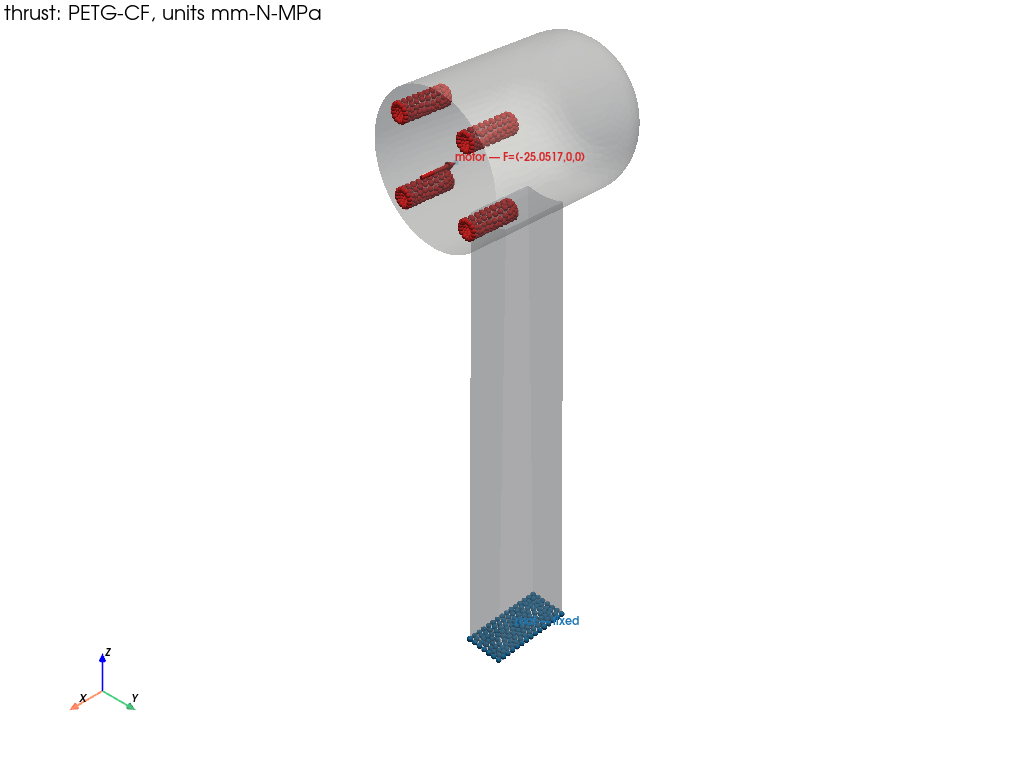

/home/user/vegeta/vegeta-cli/src/vegeta/talos/viz.py:155: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  pl.add_mesh(grid.extract_surface(), style="wireframe", color="#9aa5b1", opacity=0.25, line_width=0.5)


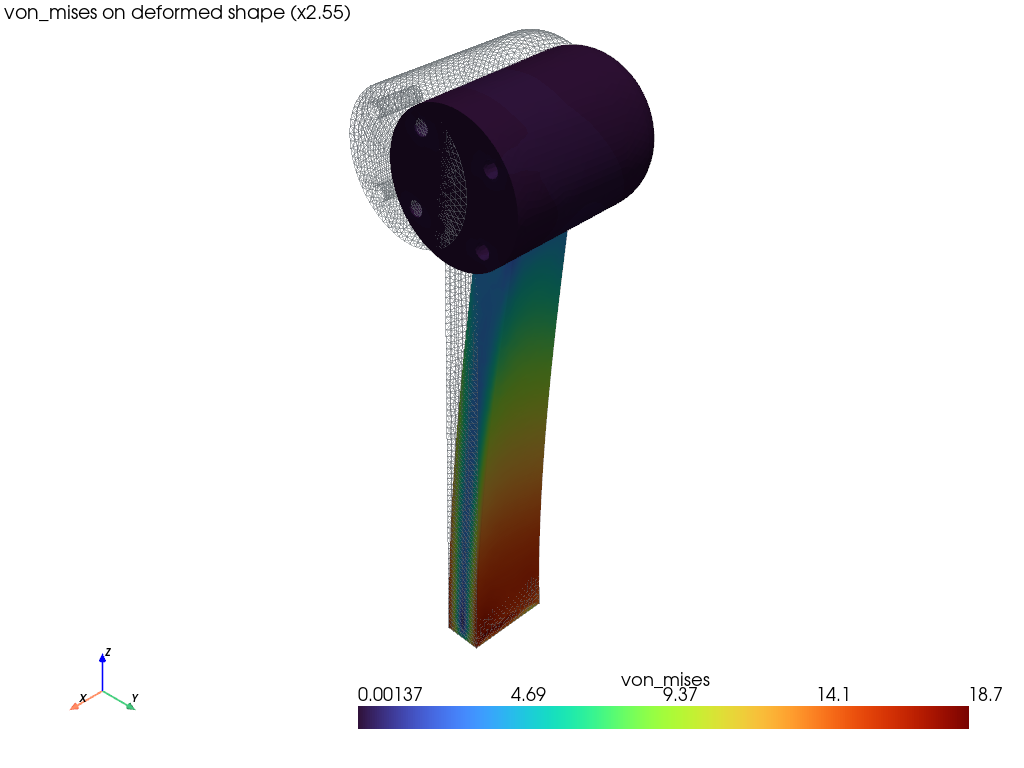

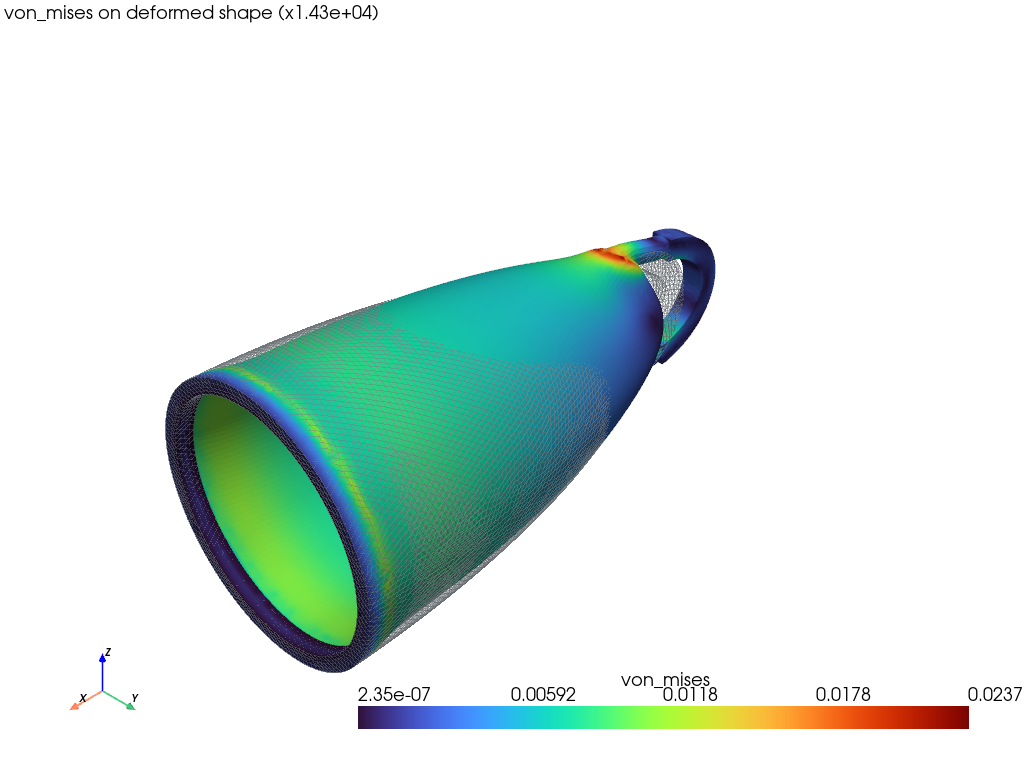

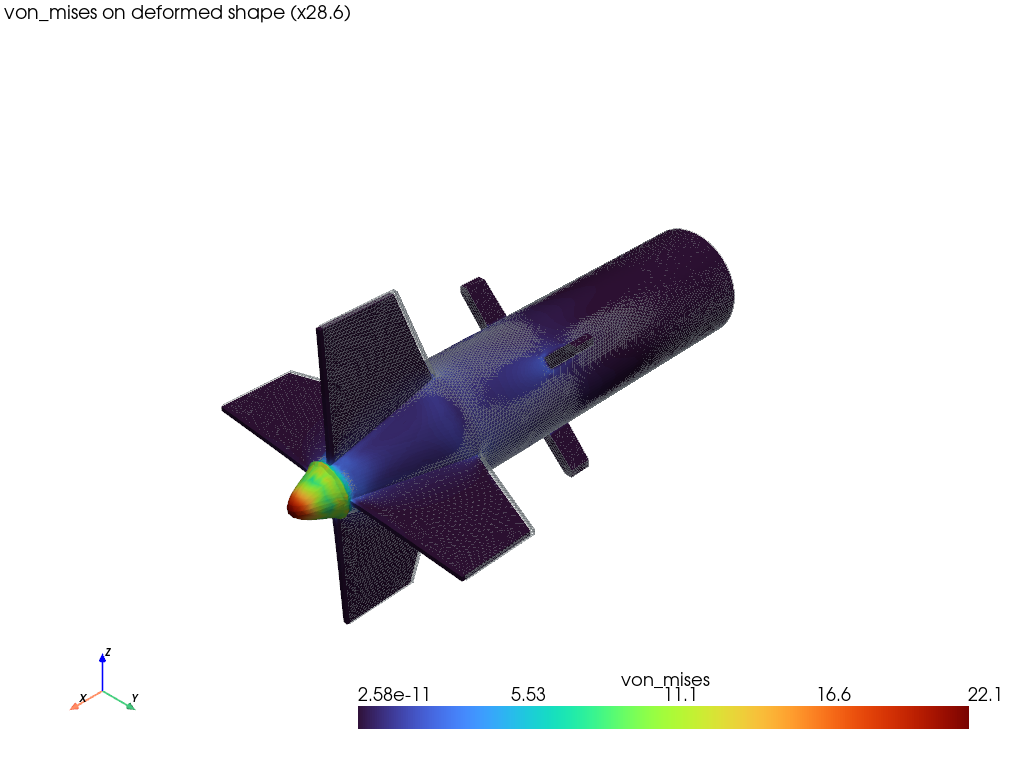

In [14]:
tviz.show(tviz.plot_problem(ARM_CASES["thrust"], res_arm["thrust"], arrow_scale=8))
tviz.show(tviz.plot_results(res_arm["landing"], field="von_mises"))
tviz.show(tviz.plot_results(res_cap["landing_15g_nose"], field="von_mises"))
tviz.show(tviz.plot_results(res_body["chute_shock"], field="von_mises"))

**Reading the numbers.** The arm has a comfortable margin at the thrust limit and under the side load; the capsule shell
takes the 15 g nose-down case. The body shell under the parachute's opening shock is the weak case: a foamed shell wall
of 2 mm is not where a shock of this size should enter the structure. **Decision for the next revision (to do):** anchor
the parachute bridle to the arm frame (the four arm roots are the stiff, heavy part) and reef the canopy to cut the
opening shock; the shell then only carries the tail cone and the fins. The FEA here records why.

## 6. Vibration: modes against the rotor lines

Modes of the arm with its motor mass (Talos, `*FREQUENCY`) and of the body shell with the capsule mass; the shaft
frequency (1P) and the blade-passing frequency (3P) of the hover and full-throttle points; the Campbell diagram and
the distance of each operating line to the nearest mode. The unbalance force (ISO G 6.3) is the excitation of §8.

arm modes [Hz]: [  46.2   92.9  267.   560.5  697.6 1580.7]
body shell modes [Hz]: [86.3 86.3 95.9 97.8 97.8 99.5]


/home/user/vegeta/vegeta-cli/src/vegeta/talos/viz.py:255: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  pl.add_mesh(grid.extract_surface(), style="wireframe", color="#9aa5b1", opacity=0.3, line_width=0.5)


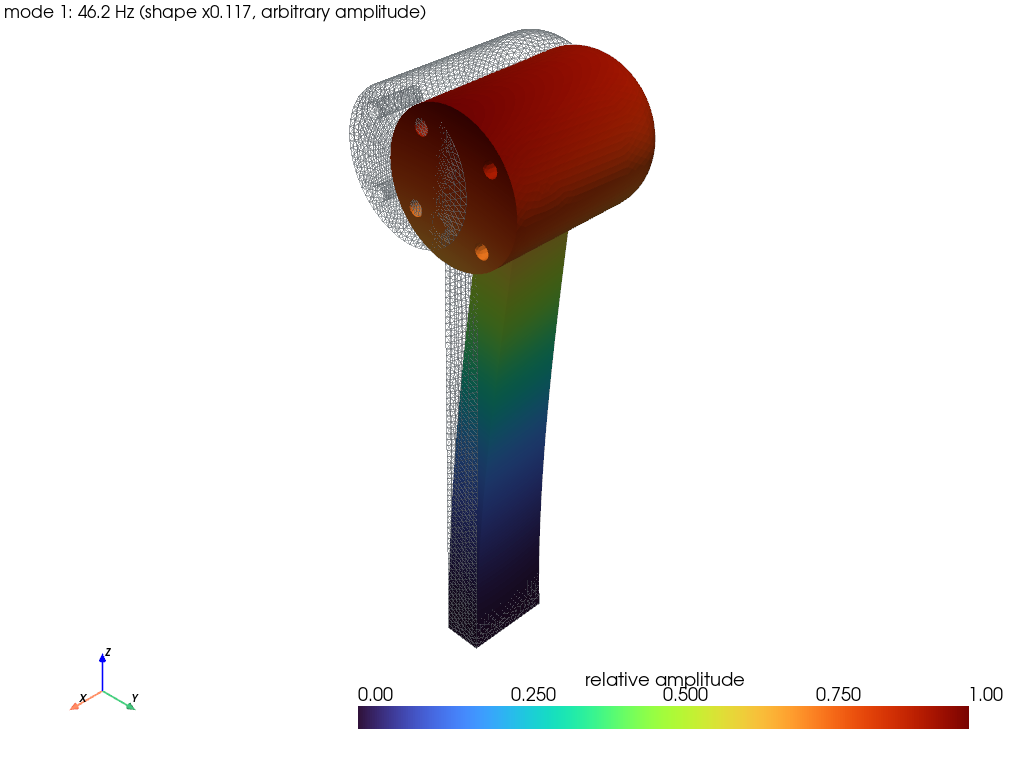

,rpm,1P_hz,3P_hz,nearest_arm_mode_hz,margin_1P,amplification_1P
hover at the depot,11695.40,194.92,584.77,266.98,0.27,2.13
hover at the site (thin air),12786.91,213.12,639.35,266.98,0.20,2.73
"full throttle, static, sea level",25228.91,420.48,1261.45,560.48,0.25,2.28


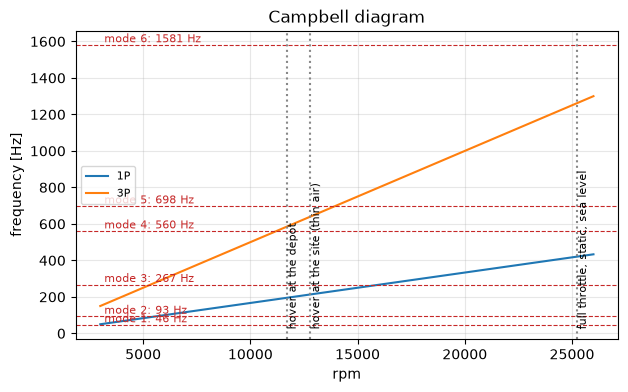

In [15]:
shutil.copytree(RUNS / "arm" / "thrust", RUNS / "arm" / "modes", dirs_exist_ok=True)          # the meshed directories
modes_arm = ARM_CASES["thrust"].solve_modes(RUNS / "arm" / "modes", n_modes=6, progress=False)
shutil.copytree(RUNS / "body" / "chute_shock", RUNS / "body" / "modes", dirs_exist_ok=True)
modes_body = BODY_CASES["chute_shock"].solve_modes(RUNS / "body" / "modes", n_modes=6, progress=False)
f_arm, f_body = modes_arm.metrics["frequencies_hz"], modes_body.metrics["frequencies_hz"]
print("arm modes [Hz]:", np.round(f_arm, 1)); print("body shell modes [Hz]:", np.round(f_body, 1))
tviz.show(tviz.plot_mode(modes_arm, mode=1))
structure = chronos.Structure(tuple(f_arm), damping_ratio=0.03, source="Talos modal, arm with motor mass, PETG-CF nominal E")
rpm_ops = {k: pts[k].rpm for k in ("hover at the depot", "hover at the site (thin air)", "full throttle, static, sea level")}
fig = structure.campbell({"1P": 1, "3P": prop.blades}, np.linspace(3000, 26000, 30), operating_rpm=rpm_ops)
pd.DataFrame({k: {"rpm": r, "1P_hz": r / 60, "3P_hz": prop.blades * r / 60, "nearest_arm_mode_hz": structure.nearest_mode(r / 60),
                  "margin_1P": structure.margin(r / 60), "amplification_1P": float(structure.amplification(r / 60)[0])} for k, r in rpm_ops.items()}).T.round(2)

## 7. The mission in flight

`designs/velutina_flight.py` is a reduced model, honest about what it is: a point mass with a body axis. The thrust
acts along the axis; the guidance tilts the body toward the acceleration it wants (speed-capped, slowing toward each
goal); the drag uses the two drag areas of §3 (axial with the slipstream increment, cross flow) blended by the angle
between the axis and the relative wind; density follows the ISA; power comes from the Boreas hover point with
momentum-theory scaling; the thrust limit is the current-limited point, falling with airspeed. Wind: the steady valley
wind, stronger with altitude, plus a first-order gust process. The guidance steers an *estimated* position with a
stated navigation error (0.25 m, a GNSS-class random walk) and a 1.2 s velocity-loop response.

Two deliveries: **set-down** on the pad at the site, and **hand-over** at the rock face — the aircraft holds a point
1.6 m off the wall at 1.5 m above the ledge for 12 s while the person takes the capsule. Then home.

set-down: 16.6 min, 135 Wh of 151 usable (90 %), max 40 m/s, peak 1284 W
   t =  345.5 s  touchdown at the site, 0.60 m from the pad centre
   t =  351.5 s  capsule released at the site
   t =  998.4 s  landed at the depot, 0.41 m off
hand-over: 16.7 min, 136 Wh of 151 usable (90 %), max 40 m/s, peak 1334 W
   t =  345.7 s  on station at the wall, 0.68 m from the hand-over point
   t =  357.6 s  capsule taken by hand at the wall
   t = 1004.1 s  landed at the depot, 0.23 m off


,start_s,duration_s,distance_m,max_speed_m_s,energy_wh,max_thrust_N,max_power_W
phase,,,,,,,
climb-out,0.0,13.0,95.2,8.0,2.1,42.9,1070.2
transit out,13.1,210.6,7305.3,40.0,34.7,54.1,1249.3
approach,223.7,113.6,1418.5,12.0,18.3,34.2,851.5
final approach,337.4,8.3,26.3,4.0,1.2,31.5,762.1
hand-over,345.7,11.9,2.2,1.1,1.9,29.5,690.9
climb-out home,357.7,12.8,93.6,8.0,1.7,33.7,835.7
transit home,370.5,523.7,8076.6,40.0,64.0,64.0,1334.4
approach home,894.3,102.2,1203.9,26.7,11.2,29.9,649.3
landing,996.6,7.5,25.2,4.0,0.8,25.5,518.5


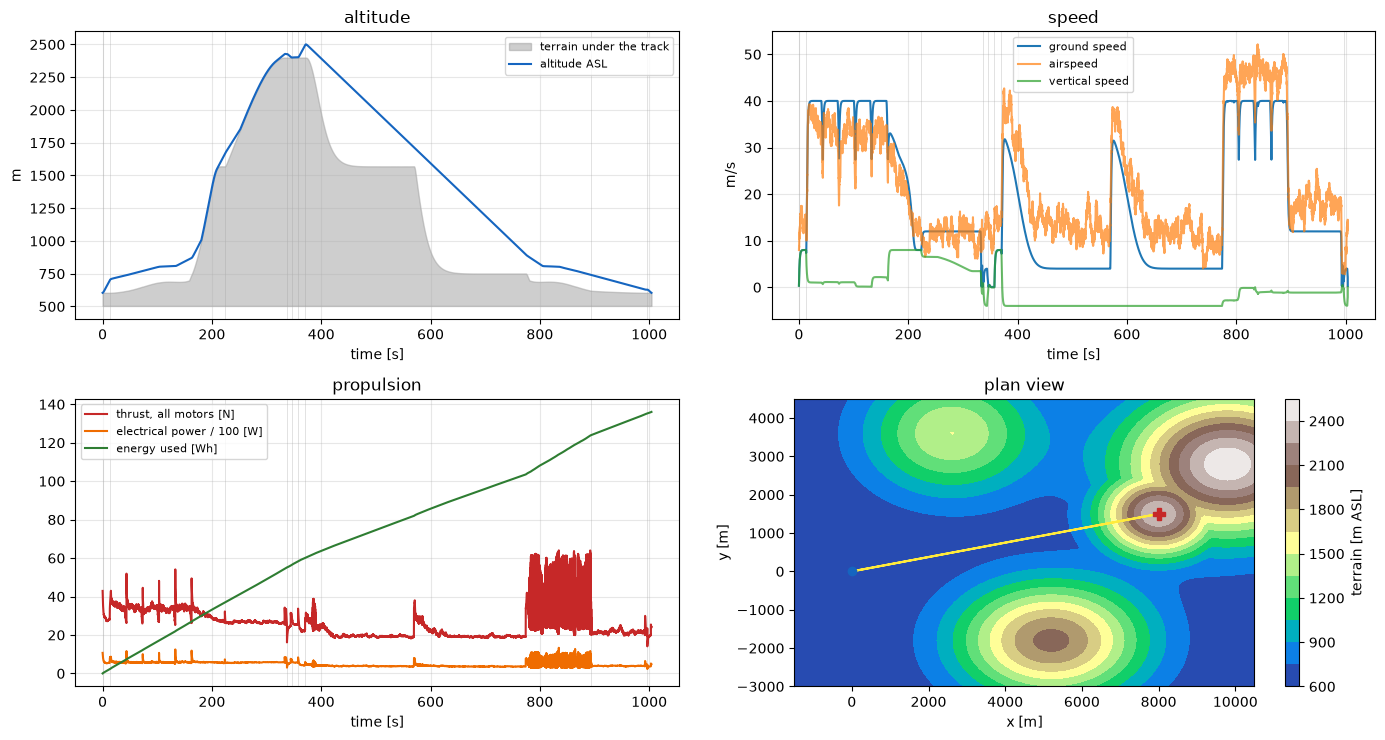

In [16]:
terrain, wind = vf.Terrain(), vf.Wind()
ac = vf.Aircraft(mass_kg=AUW, capsule_kg=CAPSULE_KG, cda_axial_m2=CDA_AXIAL_EFF, cda_cross_m2=CDA_CROSS,
                 hover_power_w_sl=tbl.loc["hover, sea level", "electrical_W_total"], hover_thrust_n_sl=W,
                 max_thrust_n_sl=T_LIMIT_SL, battery_wh=battery.usable_wh, disk_area_m2=4 * A_DISK, max_speed=JOB["dash speed [m/s]"])
ep_pad = vf.simulate(ac, terrain, wind, vf.Plan(mode="pad"))
ep_hand = vf.simulate(ac, terrain, wind, vf.Plan(mode="hand"))
for name, ep in (("set-down", ep_pad), ("hand-over", ep_hand)):
    s = ep.summary()
    print(f"{name}: {s['duration_s'] / 60:.1f} min, {s['energy_wh']:.0f} Wh of {battery.usable_wh:.0f} usable ({100 * s['energy_wh'] / battery.usable_wh:.0f} %), "
          f"max {s['max_speed_m_s']:.0f} m/s, peak {s['max_power_w']:.0f} W")
    for t, e in ep.events: print(f"   t = {t:6.1f} s  {e}")
display(ep_hand.phase_table().round(1))
fig = vf.profile_figure(ep_hand, terrain)

In [17]:
# precision over gust realisations: the set-down error on the pad; in hand-over mode the station-keeping error (after a 3 s settle)
# and the closest approach to the rock — with the GNSS-class navigation, and with a wall-relative sensor (0.05 m error, a 0.6 s loop,
# a tight position hold) that the hand-over needs
N_RUNS = 8
stats = {"set-down, GNSS navigation": vf.touchdown_statistics(ac, terrain, wind, vf.Plan(mode="pad"), n=N_RUNS),
         "hand-over, GNSS navigation": vf.touchdown_statistics(ac, terrain, wind, vf.Plan(mode="hand"), n=N_RUNS)}
ac_rel = vf.Aircraft(**{**ac.__dict__, "position_noise_m": 0.05, "response_s": 0.6, "hold_gain": 2.0})   # what a wall-relative sensor and a tight hold give
stats["hand-over, wall-relative sensing"] = vf.touchdown_statistics(ac_rel, terrain, wind, vf.Plan(mode="hand"), n=N_RUNS)
precision = pd.DataFrame({k: {kk: vv for kk, vv in v.items() if kk != "errors_m"} for k, v in stats.items()}).T
display(precision.round(2))
print("hand-over needs the capsule within arm's reach of a person on a ledge: a wall-relative sensor (vision or lidar), not GNSS alone — "
      "the table shows the station-keeping error and the closest approach to the rock with each")

,n,mean_m,p95_m,max_m,energy_mean_wh,hold_error_max_m,hold_error_max_mean_m,min_wall_distance_m
"set-down, GNSS navigation",8.0,0.42,0.59,0.60,135.35,NaN,NaN,NaN
"hand-over, GNSS navigation",8.0,0.92,1.16,1.24,136.33,0.86,0.66,1.25
"hand-over, wall-relative sensing",8.0,0.09,0.11,0.12,136.25,0.18,0.12,1.48


hand-over needs the capsule within arm's reach of a person on a ledge: a wall-relative sensor (vision or lidar), not GNSS alone — the table shows the station-keeping error and the closest approach to the rock with each


In [18]:
# margins at the site: thrust in the thin air, energy reserve, and what the gusts take
T_site = T_LIMIT_SL * RHO_SITE / RHO0
margins = pd.Series({"thrust-to-weight at the site (current limit, thin air)": T_site / W,
                     "thrust-to-weight at the site after the hand-over": T_site / ((AUW - CAPSULE_KG) * G),
                     "energy used, hand-over mission [Wh]": ep_hand.energy_wh[-1], "battery usable [Wh]": battery.usable_wh,
                     "reserve [%]": 100 * (1 - ep_hand.energy_wh[-1] / battery.usable_wh),
                     "outbound leg [min]": ep_hand.phase_table().loc["transit out", "duration_s"] / 60,
                     "time to the hand-over [min]": next(t for t, e in ep_hand.events if "hand" in e) / 60,
                     "home leg [min] (into the wind)": ep_hand.phase_table().loc["transit home", "duration_s"] / 60}, name="margins")
display(margins.round(2).to_frame())
# emergency recovery: the analytic parachute (its CFD is a to-do, see the top of the notebook)
pd.Series(chute, name="parachute from cruise height above the site (analytic)").round(2).to_frame()

,margins
"thrust-to-weight at the site (current limit, thin air)",3.09
thrust-to-weight at the site after the hand-over,3.91
"energy used, hand-over mission [Wh]",136.04
battery usable [Wh],150.96
reserve [%],9.89
outbound leg [min],3.51
time to the hand-over [min],5.76
home leg [min] (into the wind),8.73


,parachute from cruise height above the site (analytic)
terminal_speed_m_s,6.20
descent_time_s,69.20
drift_m,884.98
opening_shock_N,558.23
shock_g,27.62
touchdown_vertical_m_s,6.07


## 8. Loads over the mission → fatigue life of the arm (Chronos + Talos)

The flown hand-over mission as Chronos segments: each phase with its mean thrust per motor (the `thrust` pattern, the
arm's unit case scaled), the rotor unbalance at the phase's rpm as an excitation on the `lateral` pattern, the landing
as a side load on one pod. Rainflow on the manoeuvre levels, amplified vibration cycles from the arm's modes, damage on
the arm's FEA stress fields, and a fleet life for a rescue service flying a mix of pad and hand-over missions. The expected
outcome, and the one found: with 5 MPa at the thrust limit and an unbalance force under 1 N, fatigue is not what limits
this arm (the damage per mission is far below 1e-6 and the life comes out unbounded on the assumed curve); the hard
landing is the arm's sizing case, and the shell's parachute shock the structure's.

,duration_min,damage_per_mission,missions_to_failure,hours_to_failure
set-down,16.633333,2.560052e-10,3.906171e+09,1.082877e+09
hand-over,16.728333,2.560052e-10,3.906171e+09,1.089062e+09


fleet usage 70 % set-down / 30 % hand-over: arm life inf missions, inf flight hours (Miner, assumed curve)


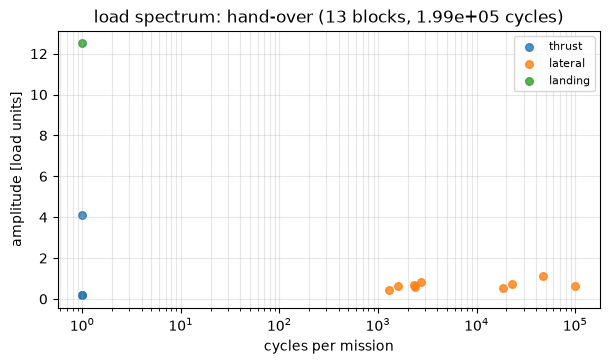

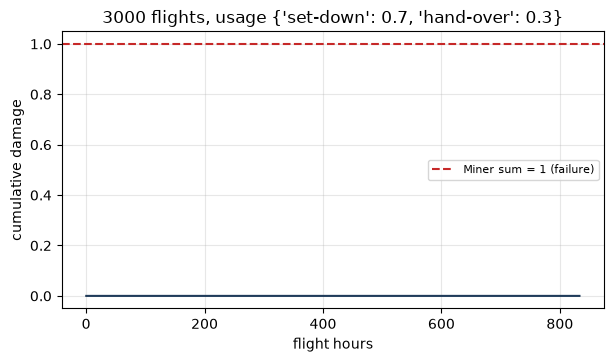

In [19]:
def mission_from_episode(ep, name):
    segs = []
    for ph, row in ep.phase_table().iterrows():
        T_per = float(np.mean(ep.thrust[np.array(ep.phase) == ph]) / 4)
        rpm = sys_depot.for_thrust(min(T_per, T_LIMIT_SL / 4 * 0.98)).rpm
        unb = boreas.excitations(prop, rpm)
        ex = (chronos.Excitation(f"unbalance {ph}", unb["shaft_hz"], unb["unbalance_force_n"], "lateral"),)
        loads = {"thrust": T_per}
        if ph == "landing":
            loads["landing"] = 25.0
        segs.append(chronos.Segment(ph, max(float(row["duration_s"]), 0.5), loads, ex))
    return chronos.Mission(name, tuple(segs), f"flown mission, {ep.t[-1] / 60:.0f} min")

missions = {"set-down": mission_from_episode(ep_pad, "set-down"), "hand-over": mission_from_episode(ep_hand, "hand-over")}
spectra = {k: chronos.build_spectrum(m, structure) for k, m in missions.items()}
for k, sp in spectra.items():
    sp.save(RUNS / f"spectrum_{k}.json")
fig = spectra["hand-over"].plot()
unit_cases = {"thrust": (res_arm["thrust"], T_MOTOR), "lateral": (res_arm["lateral_unit"], 1.0), "landing": (res_arm["landing"], 40.0)}
CURVE = talos.FatigueCurve("PETG-CF (assumed)", sigma_f=80.0, b=-0.11, ultimate=55.0, source="assumed Basquin fit; replace with coupon tests")
fatigue = {k: talos.assess_fatigue(unit_cases, spectra[k].to_dict(), CURVE, workdir=RUNS / f"fatigue_{k}") for k in missions}
life = pd.DataFrame({k: {"duration_min": missions[k].duration_h * 60, "damage_per_mission": f.result.metrics["damage_per_pass"],
                         "missions_to_failure": f.result.metrics["passes_to_failure"], "hours_to_failure": f.result.metrics["hours_to_failure"]}
                     for k, f in fatigue.items()}).T
display(life)
sim = chronos.simulate_life({k: f.result.metrics["damage_per_pass"] for k, f in fatigue.items()}, {k: missions[k].duration_h for k in missions},
                            usage={"set-down": 0.7, "hand-over": 0.3}, n_flights=3000, seed=0)
print(f"fleet usage 70 % set-down / 30 % hand-over: arm life {sim.flights_to_failure:.0f} missions, {sim.hours_to_failure:.0f} flight hours (Miner, assumed curve)")
fig = sim.plot()

## 9. Printing (Mellonia)

The capsule stands on its base ring (axis vertical, the handle up — supports under the handle loop only); an arm lies
flat on its wide face. Generic 0.2 mm PLA profile; the material and the time are what a field workshop needs to know to
print a replacement overnight.

In [20]:
prints = {"capsule": mellonia.slice_stl(cad["capsule"].artifacts["stl"], GENERIC_PLA_0_2MM, mellonia.Orientation(rotate_y=-90), RUNS / "print_capsule"),
          "arm": mellonia.slice_stl(cad["arm"].artifacts["stl"], GENERIC_PLA_0_2MM, mellonia.Orientation(rotate_x=90), RUNS / "print_arm")}
pd.DataFrame({k: {"status": r.status, "time": r.metrics.get("estimated_time"), "filament_g": r.metrics.get("filament_used_g"),
                  "filament_cm3": r.metrics.get("filament_used_cm3"), "layers": r.metrics.get("layer_count")} for k, r in prints.items()}).T

,status,time,filament_g,filament_cm3,layers
capsule,success,7h 5m 39s,84.55,68.18,875
arm,success,1h 53m 50s,21.19,17.09,150


## 10. The movie

The hand-over mission rendered in abstract air: the valley as a shaded surface, the depot and the site, the route as a
trail, the aircraft as a glyph (body, arms, rotors — drawn large to be seen over kilometres), the camera following.
Twenty-four seconds of film for seventeen minutes of flight.

In [21]:
movie, frames = vf.render_movie(ep_hand, terrain, OUT / "velutina_mountain_handover.mp4", seconds=24, fps=25, progress=True)
print(f"movie: {movie} ({len(frames)} frames)")
fig, axes = plt.subplots(2, 3, figsize=(18, 6.8))
for ax_, (label, frac) in zip(axes.flat, (("climb-out", 0.02), ("transit", 0.15), ("approach to the wall", 0.32), ("hand-over", 0.345), ("home", 0.6), ("landing", 0.99))):
    j = min(len(frames) - 1, int(frac * len(frames)))
    ax_.imshow(frames[j][:, :, ::-1]); ax_.set_axis_off(); ax_.set_title(label, fontsize=9)
fig.tight_layout()
from IPython.display import Video
Video(str(movie), embed=False)

movie frames:   0%|          | 0/600 [00:00<?, ?it/s]

movie: output/24_velutina/velutina_mountain_handover.mp4 (600 frames)


## 11. Velutina v2 — inspecting a wind turbine's blades

The courier becomes an inspector: the capsule comes off, a **camera nose** goes on (the same mass, 0.25 kg with the
gimbal). The turbine (`designs/velutina_inspection.py`, `Turbine`) is half-real: a 2 MW class onshore machine with a
90 m rotor on an 80 m tower, blades of 44 m with a 3.5 m maximum chord, **parked** for the inspection with one blade
pointing down along the tower and the other two up in a Y. The rotor faces the wind (along +x): the pressure side of
each blade faces the wind, the suction side faces the tower.

**Rudimentary aerodynamics.** The wind grows with height by a power law (exponent 0.14, open land); the tower casts a
**wind shadow**: potential flow around a cylinder upstream and beside it (the flow speeds up past the tower's sides),
a Gaussian velocity deficit in its wake that widens and fades downstream, and gusts up to 2.5 times stronger at the
wake's centre (a wake is turbulent, not just slow — and a steady wind, whatever its speed, costs the station keeping
nothing in this model: the controller trims it out; only the gusts and the navigation error move the camera). The downward blade stands in that wake
when the drone is on its suction side — the hardest station-keeping of the job. Gusts as in §7, a little weaker
(open country rather than a mountain valley).

**What the camera decides.** A 12 MP sensor behind a 24 mm lens: the size of a pixel on the blade grows with the
standoff, and a 1 mm crack must span three pixels — that fixes the **largest standoff**. The **scan speed** is limited
by motion blur (less than one pixel during the exposure) and by frame overlap. At a **suspect point** the drone must
hold until the camera has 30 sharp frames inside a 10 cm tolerance; the fraction of time it is inside comes from a
station-keeping simulation at the blade, so the **dwell time** is a number the gusts set, not a guess.

**Where the tower is.** The rotor overhangs the tower by 4 m and the blades cone upwind, so the suction side of the
downward blade faces the tower at arm's length: a camera 4 m off that surface would be inside the tower. There the path
films **obliquely**, the offset turned 60° toward the trailing edge, out beside the tower with 2.5 m clearance — in the
flow that speeds up past the tower's flank, not in its wake. The wake itself lies behind the tower, where no pass goes;
a reference point there shows what holding in it would cost.

In [22]:
turbine = vi.Turbine()
site_wind = vi.SiteWind(speed=7.0, hub_height=turbine.hub_height, gust_sigma=1.5, gust_tau_s=4.0)
camera = vi.Camera()
STANDOFF = 4.0
TURBINE = pd.Series({"hub height [m]": turbine.hub_height, "rotor diameter [m]": 2 * turbine.rotor_radius, "blade length [m]": turbine.rotor_radius - turbine.blade_root_r,
                     "max chord [m]": turbine.chord_max, "tower diameter base/top [m]": f"{turbine.tower_base_d} / {turbine.tower_top_d}",
                     "parked azimuths [deg]": str(turbine.parked_azimuths_deg), "hub-height wind [m/s]": site_wind.speed, "site altitude [m ASL]": turbine.site_altitude},
                    name="the turbine and its wind (inputs)")
display(TURBINE.to_frame())
v_scan, limits = camera.max_scan_speed(STANDOFF)
CAM = pd.Series({"pixel on the blade at the standoff [mm]": camera.gsd_mm(STANDOFF), "largest standoff for a 1 mm crack over 3 px [m]": camera.max_standoff_m(),
                 "frame footprint across [m]": camera.footprint_m(STANDOFF), "scan speed, blur limit [m/s]": limits["blur_limit_m_s"],
                 "scan speed, overlap limit [m/s]": limits["overlap_limit_m_s"], "scan speed used [m/s]": v_scan,
                 "exposure [1/s]": 1 / camera.exposure_s, "frames for one judgement": camera.sharp_frames_needed, "position tolerance [m]": camera.position_tolerance_m},
                name=f"camera at a {STANDOFF} m standoff")
display(CAM.round(3).to_frame())
fig = vi.wind_figure(turbine, site_wind, z=40.0)

,the turbine and its wind (inputs)
hub height [m],80.0
rotor diameter [m],90.0
blade length [m],43.5
max chord [m],3.5
tower diameter base/top [m],4.2 / 2.3
parked azimuths [deg],"(180.0, 60.0, 300.0)"
hub-height wind [m/s],7.0
site altitude [m ASL],300.0


,camera at a 4.0 m standoff
pixel on the blade at the standoff [mm],0.257
largest standoff for a 1 mm crack over 3 px [m],5.186
frame footprint across [m],1.028
"scan speed, blur limit [m/s]",1.028
"scan speed, overlap limit [m/s]",8.227
scan speed used [m/s],1.028
exposure [1/s],4000.000
frames for one judgement,30.000
position tolerance [m],0.100


In [23]:
# the inspector: the courier with the camera nose (0.25 kg) instead of the capsule and its load, and the wall-relative sensing of §7
CAMERA_NOSE_KG = 0.25
ac_insp = vf.Aircraft(**{**ac.__dict__, "mass_kg": AUW - CAPSULE_KG + CAMERA_NOSE_KG, "capsule_kg": 0.0,
                         "position_noise_m": 0.05, "response_s": 0.6, "hold_gain": 2.0, "max_speed": 8.0})
# station keeping at two points of the downward blade: on its pressure side (in the free wind) and on its suction side (in the tower's wake)
holds = {}
POINTS = {"blade 1 pressure side, r = 20 m (free wind)": turbine.blade_point(0, 20.0, 0.5, -1.0) + vi.pass_offset(turbine, 0, 0.5, -1.0, STANDOFF, r=20.0),
          "blade 1 suction side, r = 20 m (oblique, beside the tower)": turbine.blade_point(0, 20.0, 0.5, 1.0) + vi.pass_offset(turbine, 0, 0.5, 1.0, STANDOFF, r=20.0),
          "blade 1 leading edge, r = 40 m": turbine.blade_point(0, 40.0, 0.0, 0.0) + vi.pass_offset(turbine, 0, 0.0, 0.0, STANDOFF, r=40.0),
          "reference: 6 m behind the tower at z = 40 m (in the wake)": vi.wake_point(turbine, 40.0, 6.0)}
for name, point in POINTS.items():
    err, _ = vi.station_keeping_at_blade(ac_insp, turbine, site_wind, point, seconds=40.0, seed=1)
    dwell, inside = camera.dwell_time_s(err, 0.05)
    w = site_wind.mean(point, turbine)
    holds[name] = {"x_m": float(point[0]), "y_m": float(point[1]), "z_m": float(point[2]), "tower_distance_m": float(math.hypot(point[0], point[1]) - turbine.tower_diameter(point[2]) / 2),
                   "wind_at_point_m_s": float(np.linalg.norm(w)), "gust_factor": site_wind.turbulence_factor(point, turbine), "hold_error_rms_m": float(np.sqrt(np.mean(err ** 2))), "hold_error_max_m": float(err.max()),
                   "fraction_inside_tolerance": inside, "dwell_time_s": dwell}
HOLDS = pd.DataFrame(holds).T
display(HOLDS.round(3))
DWELL = float(HOLDS.loc[~HOLDS.index.str.startswith("reference"), "dwell_time_s"].max()) * 1.5   # the worst pass point's dwell, with margin: used at every suspect point
print(f"dwell at a suspect point: {DWELL:.1f} s (1.5 × the worst case; {camera.sharp_frames_needed} sharp frames at {camera.fps:.0f} fps need "
      f"{camera.sharp_frames_needed / camera.fps:.1f} s with a perfectly steady camera)")

,x_m,y_m,z_m,tower_distance_m,wind_at_point_m_s,gust_factor,hold_error_rms_m,hold_error_max_m,fraction_inside_tolerance,dwell_time_s
"blade 1 pressure side, r = 20 m (free wind)",-9.337,0.528,60.027,7.965,6.577,1.000,0.088,0.147,0.788,1.904
"blade 1 suction side, r = 20 m (oblique, beside the tower)",-2.756,3.987,60.027,3.460,6.938,1.000,0.088,0.147,0.788,1.904
"blade 1 leading edge, r = 40 m",-6.093,-4.273,40.055,5.818,6.257,1.000,0.090,0.147,0.788,1.904
reference: 6 m behind the tower at z = 40 m (in the wake),7.625,0.000,40.000,6.000,4.139,1.871,0.090,0.147,0.788,1.905


dwell at a suspect point: 2.9 s (1.5 × the worst case; 30 sharp frames at 20 fps need 1.5 s with a perfectly steady camera)


### The path and the flight

Each blade in four passes — leading edge, pressure side, trailing edge, suction side — root to tip and back at the
scan speed, the camera standing off the surface it films; four suspect points (two on blade 1, one each on blades 2
and 3) where it dwells; transit at 6 m/s between passes; climb-out from a van 130 m from the tower and the landing
there. The flight model of §7 follows the waypoints in the site's wind. The track error is what the camera sees: the
blade must stay in the frame (the footprint across is about a metre), so the error along a pass is a result to check,
not only the dwell.

In [24]:
plan = vi.InspectionPlan(standoff_m=STANDOFF, blades=(0, 1, 2))
waypoints, v_scan = vi.inspection_path(turbine, plan, camera, dwell_s=DWELL)
ep_insp = vi.follow_path(ac_insp, turbine, site_wind, waypoints, seed=2)
s_insp = ep_insp.summary()
print(f"{len(waypoints)} waypoints, scan at {v_scan:.2f} m/s; flown in {s_insp['duration_s'] / 60:.1f} min, {s_insp['energy_wh']:.0f} Wh of {battery.usable_wh:.0f} usable, "
      f"peak {s_insp['max_power_w']:.0f} W; track error rms {s_insp['track_error_rms_m']:.2f} m, p95 {s_insp['track_error_p95_m']:.2f} m (camera footprint {camera.footprint_m(STANDOFF):.2f} m)")
for t, e in ep_insp.events: print(f"   t = {t:6.1f} s  {e}")
tab_insp = ep_insp.table()
scan_rows = tab_insp[tab_insp.index.str.contains(":") & ~tab_insp.index.str.contains("to ")]
print(f"track error along the scanning passes: rms {math.sqrt(np.average(scan_rows['track_error_rms_m'] ** 2, weights=scan_rows['duration_s'])):.2f} m "
      f"(worst pass {scan_rows['track_error_rms_m'].max():.2f} m: {scan_rows['track_error_rms_m'].idxmax()})")
FLIGHTS = vi.flights_needed(ep_insp, battery.usable_wh, reserve=0.2)
print(f"energy per blade {', '.join(f'{v:.0f} Wh' for v in FLIGHTS['energy_per_blade_wh'].values())}, overhead {FLIGHTS['overhead_wh']:.0f} Wh -> "
      f"{FLIGHTS['flights']} flight(s) on {FLIGHTS['usable_with_reserve_wh']:.0f} Wh (20 % reserve)")
tab_insp.round(2)

267 waypoints, scan at 1.03 m/s; flown in 11.4 min, 84 Wh of 151 usable, peak 1035 W; track error rms 0.41 m, p95 1.01 m (camera footprint 1.03 m)
   t =   75.4 s  blade 1: leading edge — suspect point: 3 s of steady video recorded
   t =  114.3 s  blade 1: pressure side — suspect point: 3 s of steady video recorded
   t =  391.3 s  blade 2: trailing edge — suspect point: 3 s of steady video recorded
   t =  487.4 s  blade 3: leading edge — suspect point: 3 s of steady video recorded
track error along the scanning passes: rms 0.34 m (worst pass 0.55 m: blade 1: leading edge)
energy per blade 28 Wh, 25 Wh, 25 Wh, overhead 4 Wh -> 1 flight(s) on 121 Wh (20 % reserve)


,start_s,duration_s,energy_wh,mean_power_W,track_error_rms_m
phase,,,,,
climb-out,0.05,2.95,0.45,550.76,0.01
blade 1: to leading edge,3.05,25.35,3.04,432.41,1.15
blade 1: leading edge,28.45,42.10,5.02,429.06,0.55
blade 1: leading edge — suspect point,70.60,4.80,0.60,446.42,0.21
blade 1: leading edge,75.45,3.90,0.45,416.66,0.15
blade 1: to pressure side,79.40,2.60,0.36,506.70,0.18
blade 1: pressure side,82.05,27.40,3.38,444.58,0.41
blade 1: pressure side — suspect point,109.50,4.80,0.56,421.96,0.21
blade 1: pressure side,114.35,19.45,2.38,441.39,0.20


In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7.5))
t = ep_insp.t
ax = axes[0, 0]; ax.plot(t, ep_insp.pos[:, 2]); ax.set(xlabel="time [s]", ylabel="m", title="height"); ax.grid(alpha=0.3)
ax = axes[0, 1]; ax.plot(t, np.linalg.norm(ep_insp.vel, axis=1), label="speed"); ax.plot(t, np.linalg.norm(ep_insp.wind[:, :2], axis=1), label="wind at the aircraft", alpha=0.7)
ax.axhline(v_scan, color="#999", ls=":", label="scan speed"); ax.set(xlabel="time [s]", ylabel="m/s", title="speed and wind"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax = axes[1, 0]; ax.plot(t, ep_insp.track_error, lw=0.6); ax.axhline(camera.footprint_m(STANDOFF) / 2, color="#c62828", ls="--", label="half the frame footprint")
ax.axhline(camera.position_tolerance_m, color="#2e7d32", ls=":", label="dwell tolerance"); ax.set(xlabel="time [s]", ylabel="m", title="track error (camera off the planned line)", ylim=(0, 2)); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax = axes[1, 1]; ax.plot(t, ep_insp.power, color="#ef6c00", lw=0.6, label="power [W]"); ax.plot(t, ep_insp.energy_wh * 10, color="#2e7d32", label="energy × 10 [Wh]")
ax.set(xlabel="time [s]", title="propulsion"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
for a in axes.flat:
    last = None
    for i, lb in enumerate(ep_insp.label):
        if lb.startswith("blade") and lb.endswith("to leading edge") and lb != last:
            a.axvline(t[i], color="#ddd", lw=0.8, zorder=0); last = lb
fig.tight_layout()
# the path in 3D next to the turbine
fig = plt.figure(figsize=(7, 7)); ax3 = fig.add_subplot(111, projection="3d")
for k in range(3):
    le, te = turbine.blade_outline(k)
    ax3.plot(le[:, 0], le[:, 1], le[:, 2], color="#555"); ax3.plot(te[:, 0], te[:, 1], te[:, 2], color="#555")
ax3.plot([0, 0], [0, 0], [0, turbine.hub_height], color="#777", lw=3)
ax3.plot(ep_insp.pos[::4, 0], ep_insp.pos[::4, 1], ep_insp.pos[::4, 2], color="#ffb300", lw=0.7)
for b, name, r in plan.suspect_points:
    cf, side = next((cf, sd) for nm, cf, sd, tg in plan.passes if nm == name)
    q = turbine.blade_point(b, r, cf, side); ax3.scatter(*q, color="#c62828", s=30)
ax3.set(xlim=(-60, 60), ylim=(-60, 60), zlim=(0, 130), title="the inspection path (red: suspect points)"); ax3.set_box_aspect((1, 1, 130 / 120))
fig.tight_layout()

## 12. The inspection movie

In [26]:
movie_insp, frames_insp = vi.render_movie(ep_insp, turbine, OUT / "velutina_turbine_inspection.mp4", seconds=24, fps=25, progress=True)
print(f"movie: {movie_insp} ({len(frames_insp)} frames)")
fig, axes = plt.subplots(2, 3, figsize=(18, 6.8))
for ax_, frac in zip(axes.flat, (0.02, 0.12, 0.3, 0.5, 0.7, 0.95)):
    j = min(len(frames_insp) - 1, int(frac * len(frames_insp)))
    ax_.imshow(frames_insp[j][:, :, ::-1]); ax_.set_axis_off(); ax_.set_title(ep_insp.label[int(frac * (len(ep_insp.t) - 1))], fontsize=9)
fig.tight_layout()
Video(str(movie_insp), embed=False)

movie frames:   0%|          | 0/600 [00:00<?, ?it/s]

movie: output/24_velutina/velutina_turbine_inspection.mp4 (600 frames)


## 13. Export

In [27]:
doc = {"source": "24_velutina", "design": {"file": "designs/velutina.py", "parameters": p}, "job": JOB.to_dict(),
       "mass_budget_g": parts["mass_g"].to_dict(), "auw_kg": AUW, "capsule_kg": CAPSULE_KG,
       "aero": {"hand_axial": HAND_AXIAL, "hand_cross": HAND_CROSS, "cda_axial_used": CDA_AXIAL, "cda_axial_with_slipstream": CDA_AXIAL_EFF,
                "cfd": {f"{k:g}": (v.metrics if (v is not None and v.ok) else None) for k, v in ev_cfd.items()}, "cfd_preset": CFD_PRESET},
       "propulsion": {k: v.to_dict() for k, v in pts.items()}, "thrust_limit_N": T_LIMIT_SL, "excitations": exc, "noise": noise,
       "fea": fea.to_dict(orient="index"), "modes_hz": {"arm": f_arm, "body": f_body},
       "missions": {"set-down": ep_pad.summary(), "hand-over": ep_hand.summary(), "phases_hand": ep_hand.phase_table().to_dict(orient="index")},
       "precision": precision.to_dict(orient="index"), "margins": margins.to_dict(), "parachute_analytic": chute,
       "life": life.to_dict(orient="index"), "fleet_life": {"flights": sim.flights_to_failure, "hours": sim.hours_to_failure},
       "prints": {k: r.metrics for k, r in prints.items()}, "movie": str(movie),
       "inspection": {"turbine": TURBINE.astype(str).to_dict(), "camera": CAM.to_dict(), "station_keeping": HOLDS.to_dict(orient="index"), "dwell_s": DWELL,
                      "scan_speed_m_s": v_scan, "flight": s_insp, "phases": tab_insp.reset_index().to_dict(orient="records"), "flights_needed": FLIGHTS, "movie": str(movie_insp)},
       "todo": ["parachute in CFD (opening, canopy, body in its wake)", "propeller guards for the hand-over and the blade inspection", "four rotor disks in the whole-aircraft CFD",
                "bridle anchored to the arm frame, reefed canopy", "coupon tests of the printed materials", "FULL CFD preset on a workstation",
                "v2: the camera nose as a CAD part, a blade-relative sensor (the blade in the camera's own frame), the turbine's wake with the rotor turning slowly"]}
(RUNS / "velutina.json").write_text(json.dumps(doc, indent=2, default=float))
print("written:", RUNS / "velutina.json")

written: _runs/velutina/velutina.json
